# 基础流程
1. 理论框架：这个算法解决什么问题
2. 底层逻辑：它到底在优化什么
3. 数学表达：只讲比赛够用的公式
4. sklearn 实践：完整代码
5. 代码解读：每一段为什么这么写
6. 结果解读：指标、图像、模型表现
7. 常见错误：比赛中容易踩的坑
8. 算法标准模板：以后直接放进你的算法文档
9. 作业：巩固当天内容

# Day 1:线性回归

X shape: (442, 10)
y shape: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.23

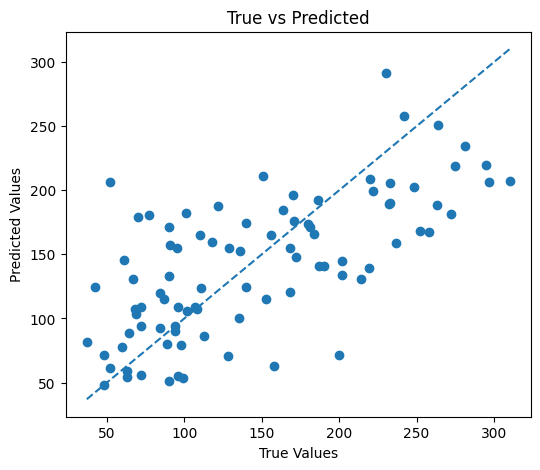

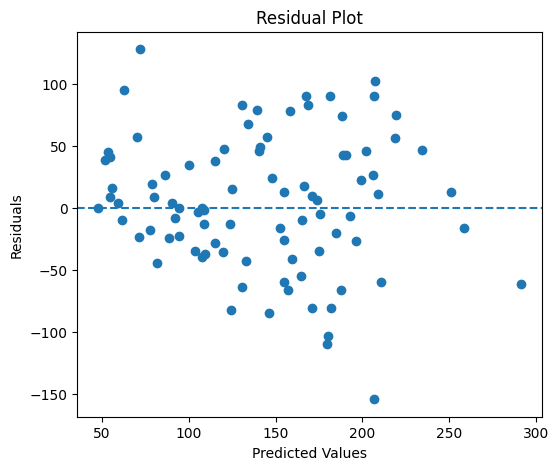

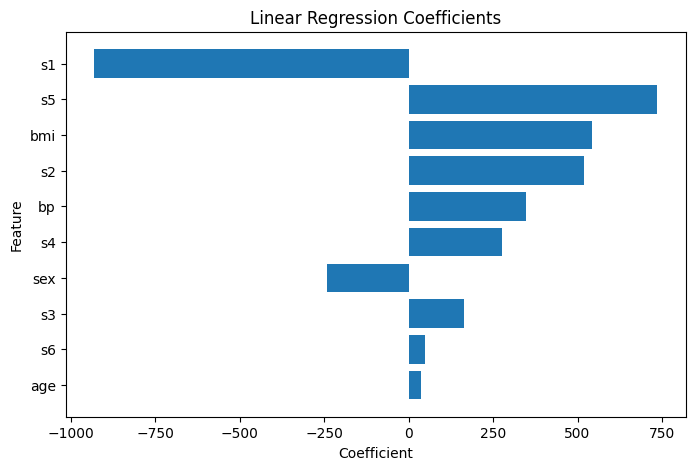

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes #导入数据集
from sklearn.model_selection import train_test_split #导入训练集测试集划分工具
from sklearn.linear_model import LinearRegression #导入线性回归模型
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score #导入评价指标：均方误差MSE，平均绝对误差MAE，R方

#1.加载数据
data=load_diabetes()
X=data.data
y=data.target

print("X shape:",X.shape)
print("y shape:",y.shape)
print("Feature names:",data.feature_names)

#2.转成DataFrame
X_df=pd.DataFrame(X,columns=data.feature_names)
y_series=pd.Series(y,name="target")

df=pd.concat([X_df,y_series],axis=1) #把 X_df 和 y_series 按列拼接起来

print(df.head())
print(df.describe())

#3.划分训练集和测试集
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:",X_train.shape)
print("X_test shape:",X_test.shape)

#4.建立并训练模型
model = LinearRegression()

model.fit(X_train, y_train)

#5.查看模型参数
print("Intercept:", model.intercept_) #model.intercept_:截距
print("Coefficients:", model.coef_) #model.coef_:系数

coef_df = pd.DataFrame({
    "feature": data.feature_names,
    "coef": model.coef_
})

coef_df["abs_coef"] = coef_df["coef"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False)

print(coef_df)

#6.预测
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

#7.计算评价指标
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)

print("Train R2:", train_r2)
print("Test R2:", test_r2)


#8.可视化
#图一：真实值vs预测值
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_test_pred)

min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())

#完美预测线，斜率为 1 的线
plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted")
plt.show()

#图二：残差图
residuals = y_test - y_test_pred

plt.figure(figsize=(6, 5))
plt.scatter(y_test_pred, residuals)
plt.axhline(y=0, linestyle="--") #画一条 y=0 的水平线

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

#图三：系数图
plt.figure(figsize=(8, 5))
plt.barh(coef_df["feature"], coef_df["coef"]) #barh(y,x):水平条形图
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Linear Regression Coefficients")
plt.gca().invert_yaxis() #意思是把 y 轴反过来，让排序第一的特征显示在最上面
plt.show()

## 算法名称：线性回归 Linear Regression

一、适用任务
线性回归适用于回归问题，即目标变量为连续数值的预测任务，例如房价预测、销量预测、疾病进展预测、收入预测等。

二、核心思想
线性回归假设目标变量可以由多个特征的线性组合近似表示。模型通过学习各个特征对应的系数和截距，建立从特征 X 到目标 y 的映射关系。

三、数学形式
预测函数：
ŷ = w1x1 + w2x2 + ... + wpxp + b

其中，ŷ 为预测值，x1 至 xp 为特征，w1 至 wp 为特征系数，b 为截距。

四、优化目标
线性回归通过最小化真实值与预测值之间的残差平方和来估计参数：
min Σ(yi - ŷi)²

五、sklearn 实现
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

六、常用评价指标
MSE：平均平方误差，对大误差更敏感。
RMSE：均方根误差，与目标变量单位一致，更容易解释。
MAE：平均绝对误差，直观且对异常值不如 MSE 敏感。
R²：决定系数，用于衡量模型对目标变量波动的解释程度，最高为 1，也可能小于 0。

七、关键可视化
1. 真实值 vs 预测值图：观察预测结果是否接近理想 y=x 直线。
2. 残差图：观察残差是否随机分布在 0 附近，判断模型是否存在系统性误差。
3. 系数图：观察不同特征在线性模型中的方向和相对影响大小。

八、优点
1. 模型简单，训练速度快。
2. 可解释性强，适合作为 baseline。
3. 适合特征与目标近似线性关系的数据。
4. 便于分析特征与目标之间的预测关联。

九、缺点
1. 表达能力有限，难以刻画复杂非线性关系。
2. 对异常值较敏感。
3. 存在多重共线性时，系数可能不稳定。
4. 如果特征量纲不同，直接比较系数大小可能误导。

十、比赛使用建议
在线性回归用于比赛建模时，通常将其作为 baseline 模型。若线性回归表现较差，可以进一步尝试 Ridge、Lasso、决策树、随机森林、GBDT 等模型。报告中应同时展示训练集和测试集指标，并结合真实值-预测值图和残差图分析模型表现。解释系数时应谨慎，不能直接将预测关联解释为因果关系。

今天我完成了 diabetes 数据集上的线性回归建模。该任务属于回归问题，目标是根据 10 个特征预测疾病进展指标。线性回归假设目标变量可以由特征的线性组合近似表示，并通过最小化残差平方和学习模型的系数和截距。模型在训练集上的 RMSE 为 53.56，测试集上的 RMSE 为 53.85；训练集 R² 为 0.528，测试集 R² 为 0.453。结果说明模型没有明显过拟合，但整体预测能力一般，只能解释测试集中约 45.3% 的目标变量波动。True vs Predicted 图显示，散点整体沿 y=x 方向分布，但离虚线较分散，且模型对高真实值样本存在低估倾向。残差图显示残差大致围绕 0 分布，但存在少数大误差点。总体来看，线性回归适合作为 baseline，优点是简单、可解释，缺点是表达能力有限，对非线性关系和异常点较敏感。下一步可以学习 Ridge 和 Lasso，通过正则化提高模型稳定性和泛化能力。

# Day 2:Ridge/Lasso与正则化

X shape: (442, 10)
y shape: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
results_df:
               model  train_rmse  test_rmse  train_mae   test_mae  train_r2  \
0  LinearRegression   53.558843  53.853446  43.483504  42.794095  0.527919   
1   Ridge_alpha_0.1   53.972063  53.446112  43.913006  42.996932  0.520607   
2     Ridge_alpha_1   58.208098  55.474462  48.805194  46.138858  0.442403   
3    Ridge_alpha_10   71.302076  66.662978  60.956061  58.030756  0.163322   
4  Lasso_alpha_0.01   53.638429  53.652208  43.549514  42.831847  0.526515   
5   Lasso_alpha_0.1   54.178024  52.897954  44.272664  42.854428  0.516941   
6     Lasso_alpha_1   62.134974  58.340172  52.958780  49.730328  0.364631   

    test_r2  coef_abs_mean  zero_coef_count  
0  0.452603     384.315951                0  
1  0.460852     207.953698                0  
2  0.419153     124.761888                0  
3  0.161226      33.991162                0  
4  0.456686     26

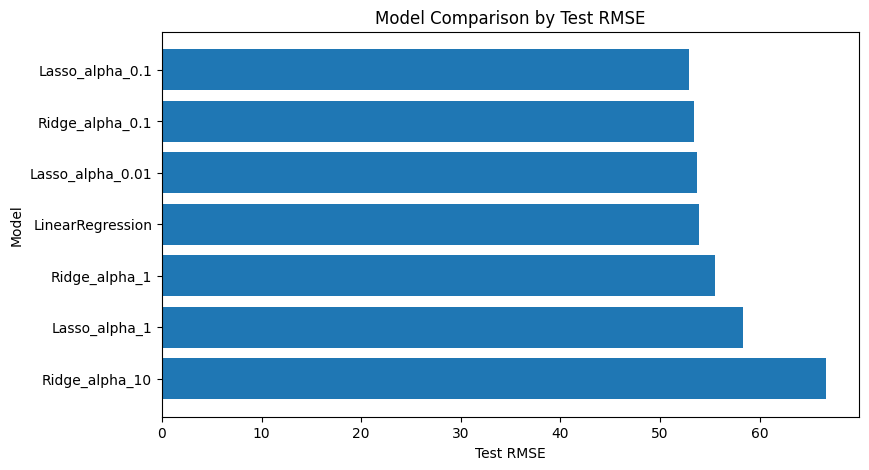

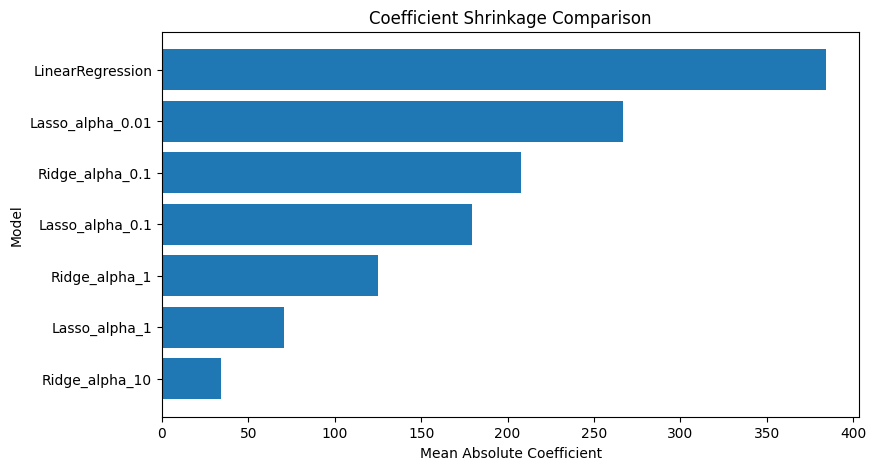

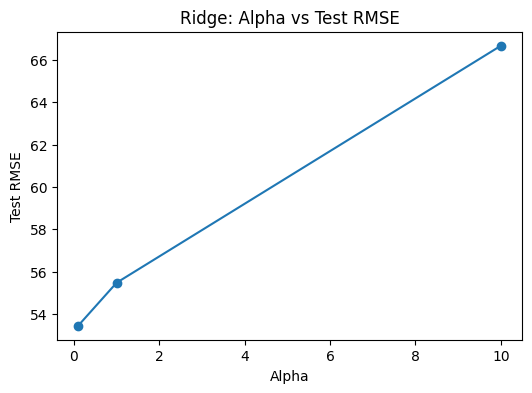

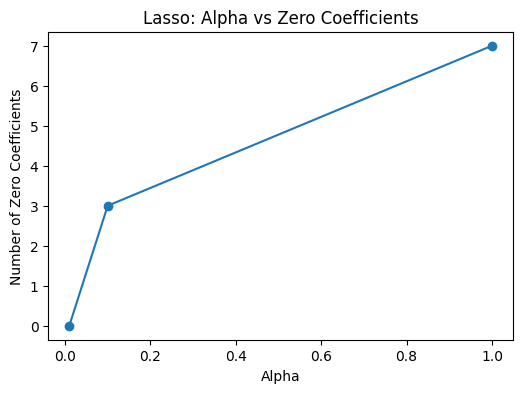

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso #Ridge：岭回归，L2正则化；Lasso：套索回归，L1正则化
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#1.加载数据
data = load_diabetes()

X = data.data
y = data.target

feature_names = data.feature_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature names:", feature_names)

#2.划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#3.建立多个模型
models = {
    "LinearRegression": LinearRegression(),
    "Ridge_alpha_0.1": Ridge(alpha=0.1),
    "Ridge_alpha_1": Ridge(alpha=1),
    "Ridge_alpha_10": Ridge(alpha=10),
    "Lasso_alpha_0.01": Lasso(alpha=0.01, max_iter=10000),#alpha=0.1：L1 正则化强度；max_iter=10000：最大迭代次数
    "Lasso_alpha_0.1": Lasso(alpha=0.1, max_iter=10000),
    "Lasso_alpha_1": Lasso(alpha=1, max_iter=10000)
}

#4.训练、预测、评价
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    #计算模型系数绝对值平均大小。Ridge/Lasso的核心就是压缩系数，如果正则化生效，通常alpha越大，coef_abs_mean越小
    coef_abs_mean = np.mean(np.abs(model.coef_)) #model.coed_:模型学到的所有系数
    #统计系数等于0的个数。Lasso的特点是可能把某些系数压成0，如果某个特征系数为0，则该特征被Lasso暂时排除在模型之外(Lasso的特征选择作用)
    zero_coef_count = np.sum(model.coef_ == 0) #统计系数等于0的个数

    results.append({
        "model": name,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "train_mae": train_mae,
        "test_mae": test_mae,
        "train_r2": train_r2,
        "test_r2": test_r2,
        "coef_abs_mean": coef_abs_mean, 
        "zero_coef_count": zero_coef_count
    })

results_df = pd.DataFrame(results)
print("results_df:\n",results_df)

#5.提取系数
coef_df = pd.DataFrame({
    "feature": feature_names
})

for name, model in models.items():
    coef_df[name] = model.coef_

print("coef_df:\n",coef_df)

#6.可视化诊断

#1.不同模型 Test RMSE 对比图(谁预测最好?)
# Test RMSE 越小，模型测试集误差越小；
# 排在最上面的模型表现最好；
# 如果 Ridge / Lasso 的 RMSE 小于 LinearRegression，说明正则化有提升。
plot_df = results_df.sort_values("test_rmse") #按照 test_rmse 从小到大排序

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(plot_df["model"], plot_df["test_rmse"])

ax.set_xlabel("Test RMSE")
ax.set_ylabel("Model")
ax.set_title("Model Comparison by Test RMSE")
#反转Y轴，RMSE最小的那个模型就会被移到图表的正上方（第一排）
ax.invert_yaxis()

plt.show()

#2.不同模型系数绝对值均值对比图(谁压缩系数更强?)
# 系数绝对值均值越小，说明模型系数整体越被压缩；
# Ridge / Lasso 的 alpha 越大，通常系数越小；
# 如果系数过小，可能出现欠拟合。
plot_df = results_df.sort_values("coef_abs_mean", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(plot_df["model"], plot_df["coef_abs_mean"])

ax.set_xlabel("Mean Absolute Coefficient")
ax.set_ylabel("Model")
ax.set_title("Coefficient Shrinkage Comparison")

ax.invert_yaxis()

plt.show()

#3.Ridge 不同 alpha 的 Test RMSE 曲线(Ridge 的 alpha 怎么影响误差?)
# alpha 改变后，测试集误差怎么变化；
# alpha 太小可能正则化不够；
# alpha 太大可能欠拟合；
# 最优 alpha 应该让测试集 RMSE 较低。
ridge_df = results_df[results_df["model"].str.contains("Ridge")].copy() #从 results_df 中筛选出 Ridge 模型

ridge_df["alpha"] = ridge_df["model"].str.extract(r"alpha_(.*)").astype(float) #从模型名字中提取 alpha

ridge_df = ridge_df.sort_values("alpha")

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(ridge_df["alpha"], ridge_df["test_rmse"], marker="o")

ax.set_xlabel("Alpha")
ax.set_ylabel("Test RMSE")
ax.set_title("Ridge: Alpha vs Test RMSE")

plt.show()

#4.Lasso 零系数数量图(Lasso 的 alpha 怎么影响特征选择?)
# alpha 越大，Lasso 越可能把更多系数压成 0；
# 零系数越多，模型越稀疏；
# 但如果太多特征被压成 0，可能欠拟合。
lasso_df = results_df[results_df["model"].str.contains("Lasso")].copy()

lasso_df["alpha"] = lasso_df["model"].str.extract(r"alpha_(.*)").astype(float)

lasso_df = lasso_df.sort_values("alpha")

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(lasso_df["alpha"], lasso_df["zero_coef_count"], marker="o")

ax.set_xlabel("Alpha")
ax.set_ylabel("Number of Zero Coefficients")
ax.set_title("Lasso: Alpha vs Zero Coefficients")

plt.show()

图一：谁预测最好？  
Lasso_alpha_0.1 的 Test RMSE 最小，说明在当前测试集划分下，它的预测误差最低。 

图二：谁压缩系数更强？   
LinearRegression 的系数绝对值均值最大；  
Ridge 和 Lasso 都压缩了系数；  
Ridge_alpha_10 和 Lasso_alpha_1 压缩最强。  

图三：Ridge 的 alpha 怎么影响误差？  
Ridge 中 alpha 从 0.1 增大到 10 后，Test RMSE 持续上升，说明 Ridge 正则化过强会使模型欠拟合。  

图 4：Lasso 的 alpha 怎么影响特征选择？  
Lasso 中 alpha 增大后，零系数数量从 0 增加到 7，说明 Lasso 正则化越强，筛掉的特征越多。

在本次实验中，Lasso_alpha_0.1 取得最低 Test RMSE，并且通过 L1 正则化将 3 个特征系数压缩为 0，实现了一定程度的特征选择。相比之下，Ridge_alpha_10 和 Lasso_alpha_1 正则化过强，系数被明显压缩，测试误差变大，表现出欠拟合倾向。

## 算法名称：Ridge 回归与 Lasso 回归

一、适用任务  
Ridge 和 Lasso 都适用于回归任务，尤其适用于线性回归中存在多重共线性、特征较多、模型系数不稳定或需要控制过拟合风险的场景。

二、核心思想  
普通线性回归只最小化训练误差，而 Ridge 和 Lasso 在训练误差基础上加入系数惩罚项，通过限制系数大小来降低模型复杂度，提高模型稳定性和泛化能力。

三、数学形式  
普通线性回归：  
min Σ(yi - ŷi)²

Ridge 回归：  
min Σ(yi - ŷi)² + αΣwj²

Lasso 回归：  
min Σ(yi - ŷi)² + αΣ|wj|

其中，α 是正则化强度。α 越大，对系数的惩罚越强。  

四、Ridge 与 Lasso 的区别  
Ridge 使用 L2 正则化，主要作用是压缩系数，使系数整体变小，但通常不会将系数压缩为 0。它适合处理多重共线性和希望保留大部分特征的情况。

Lasso 使用 L1 正则化，既可以压缩系数，也可能将部分系数压缩为 0，因此具有特征选择作用。它适合特征较多，并希望得到较稀疏模型的情况。

五、sklearn 实现  
from sklearn.linear_model import Ridge, Lasso  

ridge = Ridge(alpha=1)  
ridge.fit(X_train, y_train)  
ridge_pred = ridge.predict(X_test)  

lasso = Lasso(alpha=0.1, max_iter=10000)  
lasso.fit(X_train, y_train)  
lasso_pred = lasso.predict(X_test)  

六、关键参数  
alpha：正则化强度。alpha 越大，系数惩罚越强；alpha 过小接近普通线性回归，alpha 过大可能导致欠拟合。  
max_iter：Lasso 等迭代优化模型的最大迭代次数，用于避免模型未收敛。  

七、常用评价指标  
RMSE：衡量预测误差规模。  
MAE：衡量平均绝对误差。  
R²：衡量模型解释目标变量波动的能力。  
coef_abs_mean：观察系数整体大小，判断正则化是否压缩系数。  
zero_coef_count：观察 Lasso 是否产生稀疏解，即是否将部分特征系数压缩为 0。  

八、关键可视化  
1. 不同模型 Test RMSE 对比图：比较 LinearRegression、Ridge、Lasso 的预测误差。  
2. 系数绝对值均值对比图：观察正则化对系数大小的压缩效果。  
3. alpha 与 Test RMSE 曲线：观察正则化强度变化对模型泛化表现的影响。  
4. Lasso 零系数数量图：观察 Lasso 的特征选择效果。  

九、优点  
Ridge 的优点是能缓解多重共线性，提高模型稳定性，并保留所有特征。   
Lasso 的优点是能产生稀疏系数，具有特征选择能力，便于模型解释。  

十、缺点  
Ridge 不能直接进行特征选择，所有特征通常都会保留。  
Lasso 在特征强相关时可能不稳定，可能随机选择其中一个相关特征。  
二者都依赖 alpha 的选择，alpha 不合适会导致正则化不足或欠拟合。  

十一、比赛使用建议  
Ridge 和 Lasso 常用于线性回归 baseline 的改进版本。建模时应先与普通 LinearRegression 比较，再通过验证集或交叉验证选择合适的 alpha。报告中应说明正则化项的作用，并结合 RMSE、R²、系数变化和零系数数量解释模型表现。不要简单认为正则化越强越好。

# Day 3:交叉验证Cross Validation

X shape: (442, 10)
y shape: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
              model  cv_rmse_mean  cv_rmse_std
0  LinearRegression     54.848941     2.641094
1   Ridge_alpha_0.1     54.843463     2.450555
2     Ridge_alpha_1     58.564192     1.845884
3    Ridge_alpha_10     70.765607     2.813848
4  Lasso_alpha_0.01     54.868367     2.490172
5   Lasso_alpha_0.1     54.926335     2.610106
6     Lasso_alpha_1     62.374455     2.109187


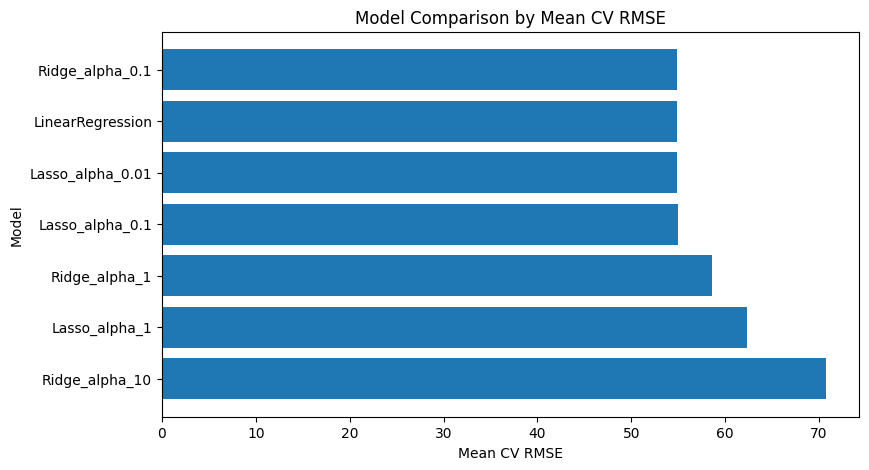

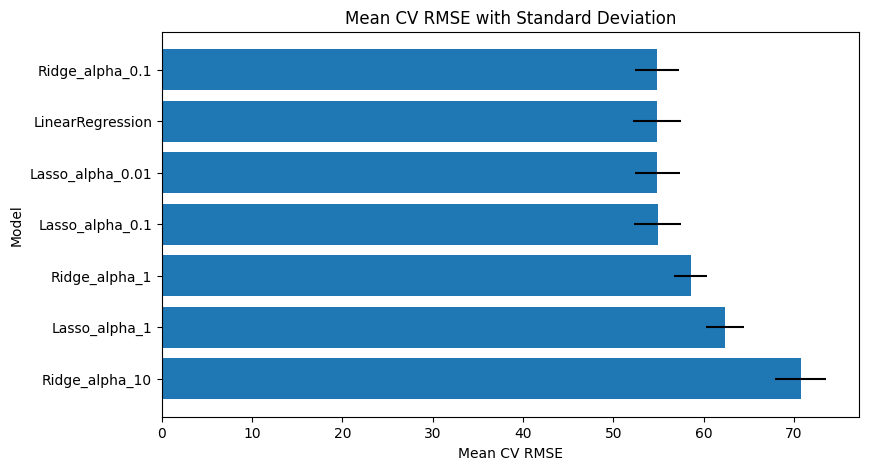

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso
#cross_val_score：自动进行交叉验证并返回每一折的分数
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, mean_squared_error

#1.加载数据
data = load_diabetes()

X = data.data
y = data.target

feature_names = data.feature_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature names:", feature_names)

#2.建立模型
models = {
    "LinearRegression": LinearRegression(),
    "Ridge_alpha_0.1": Ridge(alpha=0.1),
    "Ridge_alpha_1": Ridge(alpha=1),
    "Ridge_alpha_10": Ridge(alpha=10),
    "Lasso_alpha_0.01": Lasso(alpha=0.01, max_iter=10000),
    "Lasso_alpha_0.1": Lasso(alpha=0.1, max_iter=10000),
    "Lasso_alpha_1": Lasso(alpha=1, max_iter=10000)
}

#3.设置KFold
kf = KFold(
    n_splits=5, #5折交叉验证
    shuffle=True, #划分前打乱数据，时间序列数据不能随便shuffle
    random_state=42
)

#4.使用 cross_val_score 做交叉验证
cv_results = []

for name, model in models.items():
    neg_mse_scores = cross_val_score(
        model,
        X,
        y,
        cv=kf, #使用前面定义的kfold划分方式
        scoring="neg_mean_squared_error" #使用负均方误差作为评分
    )

    rmse_scores = np.sqrt(-neg_mse_scores)

    cv_results.append({
        "model": name,
        "cv_rmse_mean": rmse_scores.mean(),
        "cv_rmse_std": rmse_scores.std(),
        "cv_rmse_scores": rmse_scores
    })

cv_results_df = pd.DataFrame(cv_results)

print(cv_results_df[["model", "cv_rmse_mean", "cv_rmse_std"]])

#5.可视化诊断

#图1：不同模型 CV RMSE 平均值对比图
#回答哪个模型在交叉验证下平均误差最低？
plot_df = cv_results_df.sort_values("cv_rmse_mean")

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(plot_df["model"], plot_df["cv_rmse_mean"])

ax.set_xlabel("Mean CV RMSE")
ax.set_ylabel("Model")
ax.set_title("Model Comparison by Mean CV RMSE")

ax.invert_yaxis()

plt.show()

#图2：不同模型 CV RMSE 均值 + 标准差图
#回答哪个模型平均误差低？哪个模型表现更稳定？
plot_df = cv_results_df.sort_values("cv_rmse_mean")

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    plot_df["model"],
    plot_df["cv_rmse_mean"],
    xerr=plot_df["cv_rmse_std"] #画误差线，表示不同折之间 RMSE 的波动
)

ax.set_xlabel("Mean CV RMSE")
ax.set_ylabel("Model")
ax.set_title("Mean CV RMSE with Standard Deviation")

ax.invert_yaxis()

plt.show()


## 选择某个模型的最佳参数

In [2]:
#1.RidgeCV
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-4, 4, 50)

ridge_cv = RidgeCV(
    alphas=alphas,
    cv=5,
    scoring="neg_mean_squared_error"
)

ridge_cv.fit(X, y)

print("Best Ridge alpha:", ridge_cv.alpha_)

#2.LassoCV
from sklearn.linear_model import LassoCV

alphas = np.logspace(-4, 1, 50)

lasso_cv = LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=10000,
    random_state=42
)

lasso_cv.fit(X, y)

print("Best Lasso alpha:", lasso_cv.alpha_)


Best Ridge alpha: 0.0004498432668969444
Best Lasso alpha: 0.00339322177189533


## 用GridSearchCV做通用调参

In [ ]:
#后面模型复杂后，比如随机森林、SVM、XGBoost，就不会有 RandomForestCV 这种专门类了
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

param_grid = {
    "alpha": np.logspace(-4, 4, 50)
}

grid = GridSearchCV(
    estimator=Ridge(),
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

grid.fit(X, y)

print("Best params:", grid.best_params_)
print("Best CV score:", np.sqrt(-grid.best_score_))

## 方法名称：交叉验证 Cross Validation

一、适用场景  
交叉验证适用于模型评估和模型选择，尤其当样本量有限、单次 train/test split 结果不稳定时，可以更稳健地估计模型泛化表现。

二、核心思想  
交叉验证不只进行一次训练集/验证集划分，而是将数据划分为 K 份，每次使用其中 1 份作为验证集，其余 K-1 份作为训练集，重复 K 次，使每一份数据都被用作一次验证集。最终根据 K 次验证结果的平均值和标准差评价模型表现。

三、K 折交叉验证流程  
1. 将数据划分为 K 个 fold。  
2. 第 1 次使用 Fold 1 验证，其余 fold 训练。  
3. 第 2 次使用 Fold 2 验证，其余 fold 训练。  
4. 重复直到每个 fold 都作为验证集一次。  
5. 得到 K 个验证分数。  
6. 计算平均分和标准差。  

四、sklearn 实现  
from sklearn.model_selection import KFold, cross_val_score  

kf = KFold(n_splits=5, shuffle=True, random_state=42)  

scores = cross_val_score(  
    model,  
    X,  
    y,  
    cv=kf,  
    scoring="neg_mean_squared_error"  
)  

rmse_scores = np.sqrt(-scores)  

五、关键参数  
n_splits：折数，常用 5 或 10。  
shuffle：是否在划分前打乱数据。  
random_state：随机种子，用于保证结果可复现。  
scoring：评价指标，如 neg_mean_squared_error、r2、accuracy、f1 等。  

六、结果解释  
cv_rmse_mean 表示模型在不同划分下的平均预测误差，越小越好。  
cv_rmse_std 表示不同折之间表现波动，越小表示模型越稳定。  
模型选择时不能只看平均误差，也要关注稳定性。  

七、优点   
1. 比单次train/test split 更稳定。  
2. 能更充分利用有限样本。  
3. 适合模型比较和超参数选择。  
4. 可以降低随机划分带来的偶然性。  

八、缺点  
1. 计算成本更高，因为要训练 K 次模型。  
2. 对时间序列、空间数据、分组数据不能随便使用普通 KFold。  
3. 如果预处理没有放进 Pipeline，可能产生数据泄露。  

九、比赛使用建议  
比赛中应优先使用交叉验证进行模型选择和调参，而不是反复使用测试集调参。测试集应尽量只用于最终评估。对于 Ridge、Lasso 等带超参数的模型，可以使用 RidgeCV、LassoCV 或 GridSearchCV 选择参数。  

# Day 4:逻辑回归Logistic Regression

X shape: (569, 30)
y shape: (569,)
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']
Target names: ['malignant' 'benign']
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1: 0.9861111111111112
ROC AUC: 0.9953703703703703
[[41  1]
 [ 1 71]]


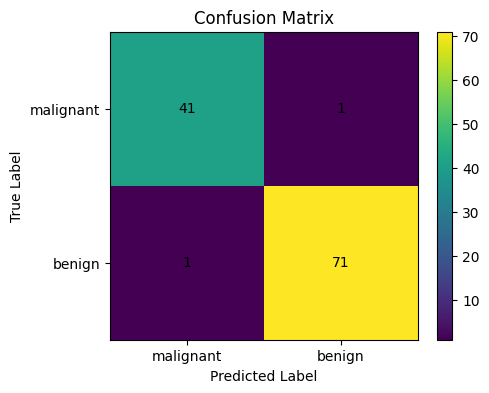

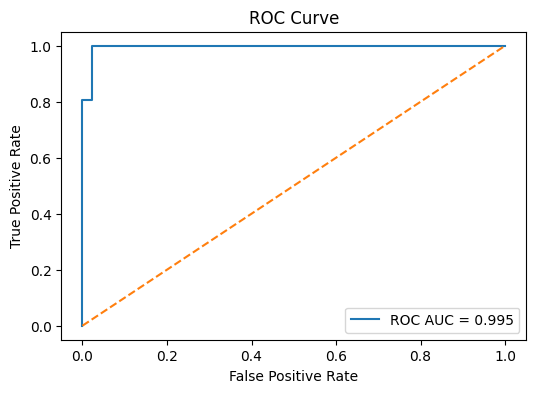

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer #乳腺癌二分类数据集
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler #标准化
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, #accuracy准确率=(TP+TN)/(TP+TN+FP+FN)
    precision_score, #precision精确率=TP/(TP+FP)
    recall_score, #recall召回率=TP/(TP+FN)
    f1_score, #F1=2*precision*recall/(precision+recall)
    confusion_matrix,
    roc_auc_score,
    roc_curve #ROC 曲线看 TPR 和 FPR 的权衡
)

#1.加载数据
data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names
target_names = data.target_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature names:", feature_names[:5])
print("Target names:", target_names)

#2.划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #按照y的类别比例分层抽样，在划分训练集和测试集时，尽量保持 y 的类别比例一致
)

#3.标准化
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) #fit_transform: fit:根据数据学习当前对象需要的内部参数; transform:用这些均值和标准差转换训练集
X_test_scaled = scaler.transform(X_test)

#4.建立并训练模型
model = LogisticRegression(max_iter=10000)

model.fit(X_train_scaled, y_train)

#5.预测类别与预测概率
y_pred = model.predict(X_test_scaled) #输出最终类别
y_proba = model.predict_proba(X_test_scaled)[:, 1] #输出正类概率

#6.计算评价指标
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Accuracy:", acc)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC AUC:", auc)

#7.混淆矩阵 行是真实类别，列是预测类别
cm = confusion_matrix(y_test, y_pred)

print(cm)

#8.可视化诊断
#图一：混淆矩阵图
#对角线为预测正确，非对角线为预测错误
#对角线元素越高越好，表示预测标签等于真实标签的样本越多
fig, ax = plt.subplots(figsize=(5, 4))

im = ax.imshow(cm) #imshow 会根据数值大小给不同格子着色。数值越大，颜色越偏向色条高值区域

ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")

ax.set_xticks([0, 1]) #设置横轴和纵轴的刻度位置
ax.set_yticks([0, 1])
ax.set_xticklabels(target_names) #把 0 和 1 换成类别名称；0 → malignant，1 → benign
ax.set_yticklabels(target_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(im, ax=ax) #添加颜色条

plt.show()

#图二：ROC曲线
#TPR=recall=TP/(TP+FN) FPR=FP/(FP+TN)
fpr, tpr, thresholds = roc_curve(y_test, y_proba) #FPR：假阳性率；TPR：真阳性率，也就是 Recall

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(fpr, tpr, label=f"ROC AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()

plt.show()

## 算法名称：逻辑回归 Logistic Regression

一、适用任务  
逻辑回归主要用于分类任务，尤其适用于二分类问题，例如违约预测、疾病诊断、客户流失预测、欺诈识别等。  

二、核心思想  
逻辑回归先对特征进行线性组合，得到 z = w1x1 + w2x2 + ... + wpxp + b，再通过 sigmoid 函数将 z 映射到 0 到 1 之间，得到样本属于正类的概率。最后根据分类阈值将概率转换为类别标签。  

三、数学形式  
线性部分：  
z = w1x1 + w2x2 + ... + wpxp + b  

Sigmoid 函数：  
p = 1 / (1 + exp(-z))  

分类规则：  
若 p >= 0.5，则预测为 1；  
若 p < 0.5，则预测为 0。  

四、sklearn 实现  
from sklearn.linear_model import LogisticRegression  

model = LogisticRegression(max_iter=10000)  
model.fit(X_train_scaled, y_train)  

y_pred = model.predict(X_test_scaled)  
y_proba = model.predict_proba(X_test_scaled)[:, 1]  

五、关键参数  
max_iter：最大迭代次数，用于避免模型未收敛。  
C：正则化强度的倒数，C 越小正则化越强；后续调参时再深入。  
penalty：正则化类型，如 l2、l1 等；当前阶段先默认 l2。  

六、常用评价指标  
Accuracy：整体预测正确率。  
Precision：预测为正类的样本中，真正为正类的比例。
Recall：真实正类样本中，被模型找出来的比例。  
F1：Precision 和 Recall 的调和平均。  
ROC AUC：衡量模型整体区分正负类的能力。  

七、关键可视化  
1. 混淆矩阵：观察 TP、TN、FP、FN，判断模型错在哪里。  
2. ROC 曲线：观察不同阈值下 TPR 和 FPR 的关系，评估模型区分能力。  

八、优点  
1. 模型简单，训练速度快。  
2. 输出概率，便于解释和调整阈值。  
3. 可解释性较强，可以查看特征系数方向。    
4. 适合作为分类任务 baseline。  

九、缺点  
1. 本质是线性分类模型，难以捕捉复杂非线性关系。  
2. 对特征尺度敏感，通常需要标准化。  
3. 类别不平衡时不能只看 Accuracy。  
4. 默认阈值 0.5 不一定适合所有业务场景。  

十、比赛使用建议  
逻辑回归适合作为分类任务 baseline。建模时应标准化特征，并同时报告 Accuracy、Precision、Recall、F1 和 ROC AUC。若类别不平衡，应重点关注 Precision、Recall、F1、AUC，而不是只看 Accuracy。报告中应结合混淆矩阵说明模型主要错误类型。  

# Day 5：KNN + 标准化 + K 值选择

X shape: (569, 30)
y shape: (569,)
Target names: ['malignant' 'benign']
        model  accuracy  precision    recall        f1   roc_auc
0     KNN_raw  0.912281   0.942857  0.916667  0.929577  0.955853
1  KNN_scaled  0.956140   0.958904  0.972222  0.965517  0.978836
    k  accuracy  precision    recall        f1   roc_auc
0   1  0.938596   0.957746  0.944444  0.951049  0.936508
1   3  0.982456   0.972973  1.000000  0.986301  0.983466
2   5  0.956140   0.958904  0.972222  0.965517  0.978836
3   7  0.973684   0.960000  1.000000  0.979592  0.988426
4   9  0.973684   0.960000  1.000000  0.979592  0.994378
5  11  0.973684   0.960000  1.000000  0.979592  0.991071
6  15  0.973684   0.960000  1.000000  0.979592  0.992725
7  21  0.964912   0.947368  1.000000  0.972973  0.992560


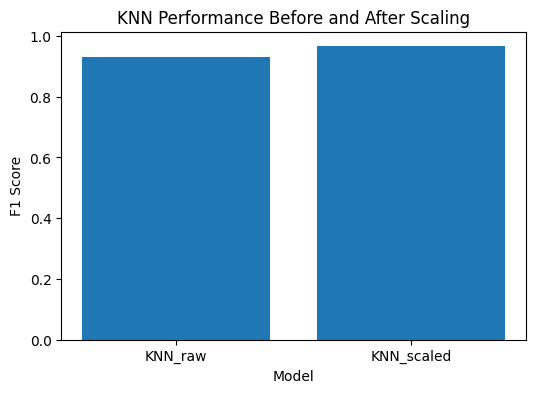

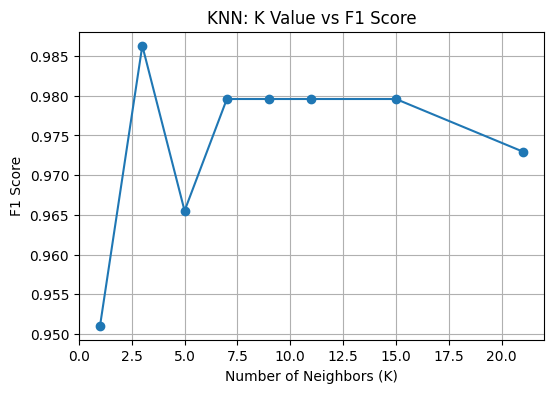

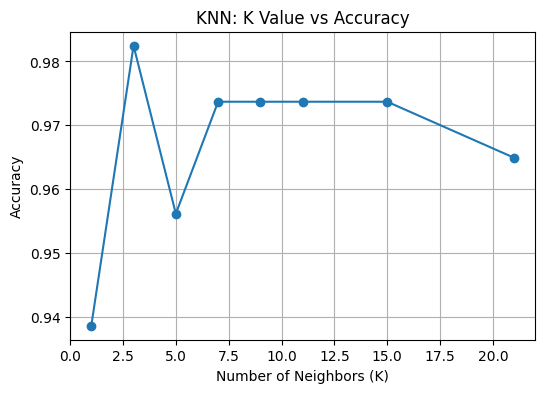

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

#1.加载数据
data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names
target_names = data.target_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target names:", target_names)

#2.划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#3.先训练一个未标准化KNN
knn_raw = KNeighborsClassifier(n_neighbors=5)

knn_raw.fit(X_train, y_train) #fit作用：保存训练样本和对应标签，方便预测时查找最近邻

y_pred_raw = knn_raw.predict(X_test)
y_proba_raw = knn_raw.predict_proba(X_test)[:, 1]

#4.再训练一个标准化KNN
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_scaled = KNeighborsClassifier(n_neighbors=5)

knn_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = knn_scaled.predict(X_test_scaled)
y_proba_scaled = knn_scaled.predict_proba(X_test_scaled)[:, 1]

#5.定义评价函数
def evaluate_classifier(y_true, y_pred, y_proba=None):
    result = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    }
    
    if y_proba is not None:
        result["roc_auc"] = roc_auc_score(y_true, y_proba)
    
    return result

#6.比较未标准化和标准化结果
raw_result = evaluate_classifier(y_test, y_pred_raw, y_proba_raw)
scaled_result = evaluate_classifier(y_test, y_pred_scaled, y_proba_scaled)

comparison_df = pd.DataFrame([
    {"model": "KNN_raw", **raw_result}, ## **raw_result为字典合并写法，输出raw_result
    {"model": "KNN_scaled", **scaled_result}
])

print(comparison_df)

#7.尝试不同K值
k_values = [1, 3, 5, 7, 9, 11, 15, 21]

k_results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    result = evaluate_classifier(y_test, y_pred, y_proba)
    
    k_results.append({
        "k": k,
        **result
    })

k_results_df = pd.DataFrame(k_results)

print(k_results_df)

#8.可视化诊断
#标准化前后F1对比图
#作用：标准化有没有改善 KNN 表现？
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(comparison_df["model"], comparison_df["f1"])

ax.set_xlabel("Model")
ax.set_ylabel("F1 Score")
ax.set_title("KNN Performance Before and After Scaling")

plt.show()

#K值与F1的关系图
#作用：哪个K值下模型表现较好；K太小或太大时表现如何变化？
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(k_results_df["k"], k_results_df["f1"], marker="o")

ax.set_xlabel("Number of Neighbors (K)")
ax.set_ylabel("F1 Score")
ax.set_title("KNN: K Value vs F1 Score")

ax.grid(True)

plt.show()

#K值与Accuracy的关系图
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(k_results_df["k"], k_results_df["accuracy"], marker="o")

ax.set_xlabel("Number of Neighbors (K)")
ax.set_ylabel("Accuracy")
ax.set_title("KNN: K Value vs Accuracy")

ax.grid(True)

plt.show()

## 算法名称：K 近邻算法 K-Nearest Neighbors, KNN

一、适用任务  
KNN 可用于分类和回归任务。分类任务中，KNN 根据样本附近 K 个最近邻的类别投票决定预测类别；回归任务中，可以根据最近邻目标值的平均值进行预测。本阶段主要用于分类任务。  

二、核心思想  
KNN 的基本假设是相似样本具有相似标签。对于一个待预测样本，算法先计算它与训练集中所有样本的距离，找到距离最近的 K 个样本，再根据这 K 个邻居的类别多数投票确定预测类别。  

三、数学形式  
常用距离为欧氏距离：  
distance(x, z) = sqrt((x1-z1)^2 + (x2-z2)^2 + ... + (xp-zp)^2)  

分类规则：  
预测类别 = K 个最近邻中出现次数最多的类别。  

四、sklearn 实现  
from sklearn.neighbors import KNeighborsClassifier  

model = KNeighborsClassifier(n_neighbors=5)  
model.fit(X_train_scaled, y_train)  
y_pred = model.predict(X_test_scaled)  
y_proba = model.predict_proba(X_test_scaled)[:, 1]  

五、关键参数  
n_neighbors：邻居数量 K。K 太小，模型容易对噪声敏感，可能过拟合；K 太大，模型过于平滑，可能欠拟合。  
weights：邻居投票权重。uniform 表示所有邻居等权重，distance 表示距离越近权重越大。  
metric：距离度量方式，默认常用 Minkowski 距离；在 p=2 时相当于欧氏距离。  

六、常用评价指标  
Accuracy：整体预测正确率。  
Precision：预测为正类的样本中真实为正类的比例。  
Recall：真实正类中被识别出来的比例。  
F1：Precision 和 Recall 的综合指标。  
ROC AUC：模型区分正负类的整体能力。  

七、关键可视化  
1. 标准化前后指标对比图：观察标准化是否改善 KNN 表现。  
2. K 值 vs F1 曲线：观察不同 K 值下模型表现变化，辅助选择合适 K。  

八、优点   
1. 思想简单，容易理解。  
2. 不需要显式训练复杂参数。  
3. 对非线性分类边界有一定适应能力。  
4. 适合作为基础分类模型和教学模型。  

九、缺点  
1. 对特征尺度非常敏感，通常必须标准化。  
2. 预测时需要计算与训练样本的距离，数据量大时预测较慢。  
3. 对无关特征和噪声特征较敏感。  
4. K 值选择对模型表现影响较大。  
5. 高维数据中距离可能变得不可靠。  

十、比赛使用建议  
KNN 可作为分类 baseline 之一，尤其适合用于理解标准化和 K 值选择。但在大规模、高维、噪声较多的数据中，KNN 往往不如树模型和集成模型稳定。使用 KNN 时应先进行标准化，并通过验证集或交叉验证选择合适的 n_neighbors。

# Day 6：Decision Tree决策树

X shape: (569, 30)
y shape: (569,)
Target names: ['malignant' 'benign']
Full Tree Train Accuracy: 1.0
Full Tree Test Accuracy: 0.9122807017543859
Full Tree Test F1: 0.9285714285714286
Full Tree ROC AUC: 0.9156746031746031
Pruned Tree Train Accuracy: 0.9758241758241758
Pruned Tree Test Accuracy: 0.9385964912280702
Pruned Tree Test F1: 0.9517241379310345
Pruned Tree ROC AUC: 0.9446097883597884
           model  train_accuracy  test_accuracy   test_f1  test_auc
0      Full Tree        1.000000       0.912281  0.928571  0.915675
1  Max Depth = 3        0.975824       0.938596  0.951724  0.944610


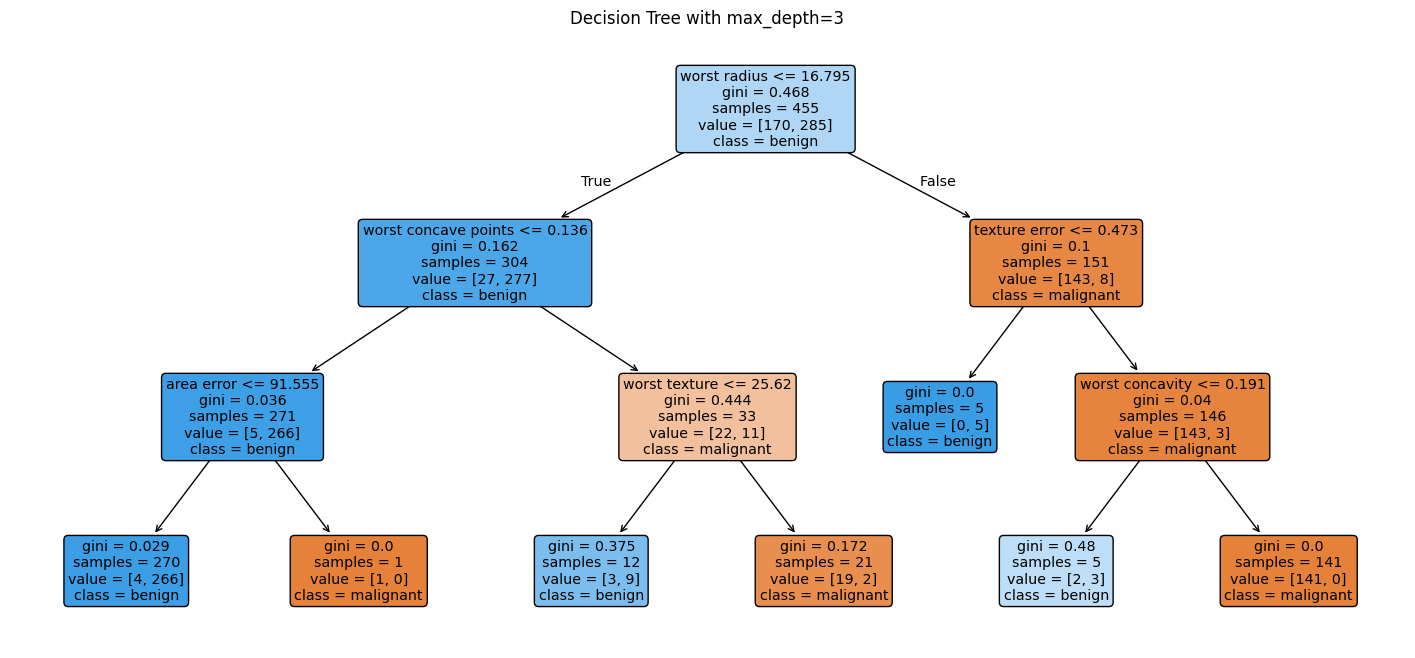

   max_depth  train_accuracy  test_accuracy
0          1        0.923077       0.921053
1          2        0.958242       0.894737
2          3        0.975824       0.938596
3          4        0.986813       0.938596
4          5        0.993407       0.921053
5          6        0.997802       0.912281
6          7        1.000000       0.912281
7          8        1.000000       0.912281
8          9        1.000000       0.912281
9         10        1.000000       0.912281


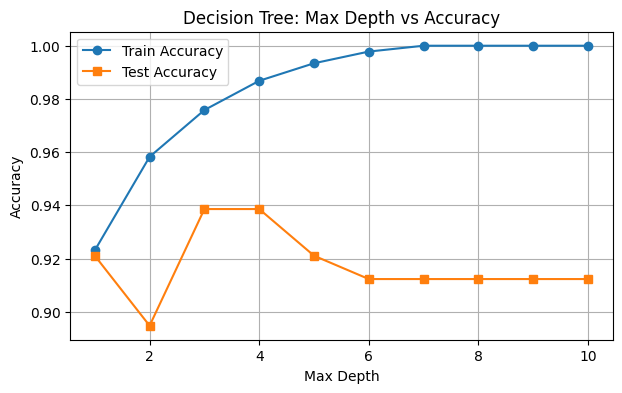

                 feature  importance
20          worst radius    0.763804
27  worst concave points    0.127061
11         texture error    0.047673
21         worst texture    0.033652
26       worst concavity    0.017869
13            area error    0.009940
0            mean radius    0.000000
16       concavity error    0.000000
28        worst symmetry    0.000000
25     worst compactness    0.000000


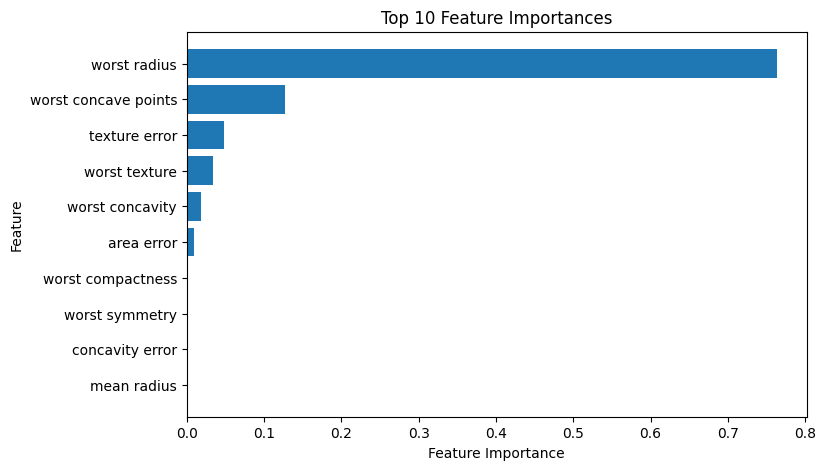

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

#1.加载数据
data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names
target_names = data.target_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target names:", target_names)

#2.划分数据
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#3.先训练一棵完全不限制的树
tree_full = DecisionTreeClassifier(
    random_state=42
)

tree_full.fit(X_train, y_train)

#4.预测
y_train_pred_full = tree_full.predict(X_train)
y_test_pred_full = tree_full.predict(X_test)

y_test_proba_full = tree_full.predict_proba(X_test)[:, 1]

#5.评价模型
train_acc_full = accuracy_score(
    y_train,
    y_train_pred_full
)

test_acc_full = accuracy_score(
    y_test,
    y_test_pred_full
)

test_f1_full = f1_score(
    y_test,
    y_test_pred_full
)

test_auc_full = roc_auc_score(
    y_test,
    y_test_proba_full
)

print("Full Tree Train Accuracy:", train_acc_full)
print("Full Tree Test Accuracy:", test_acc_full)
print("Full Tree Test F1:", test_f1_full)
print("Full Tree ROC AUC:", test_auc_full)

#6.再训练一棵限制深度的树
tree_pruned = DecisionTreeClassifier(
    max_depth=3, #最大深度，表示树最多长到 3 层左右的限制结构
    random_state=42
)

tree_pruned.fit(X_train, y_train)

#7.预测限制后的树
y_train_pred_pruned = tree_pruned.predict(X_train)
y_test_pred_pruned = tree_pruned.predict(X_test)

y_test_proba_pruned = tree_pruned.predict_proba(X_test)[:, 1]

train_acc_pruned = accuracy_score(
    y_train,
    y_train_pred_pruned
)

test_acc_pruned = accuracy_score(
    y_test,
    y_test_pred_pruned
)

test_f1_pruned = f1_score(
    y_test,
    y_test_pred_pruned
)

test_auc_pruned = roc_auc_score(
    y_test,
    y_test_proba_pruned
)

print("Pruned Tree Train Accuracy:", train_acc_pruned)
print("Pruned Tree Test Accuracy:", test_acc_pruned)
print("Pruned Tree Test F1:", test_f1_pruned)
print("Pruned Tree ROC AUC:", test_auc_pruned)

#8.建一个比较表
comparison_df = pd.DataFrame([
    {
        "model": "Full Tree",
        "train_accuracy": train_acc_full,
        "test_accuracy": test_acc_full,
        "test_f1": test_f1_full,
        "test_auc": test_auc_full
    },
    {
        "model": "Max Depth = 3",
        "train_accuracy": train_acc_pruned,
        "test_accuracy": test_acc_pruned,
        "test_f1": test_f1_pruned,
        "test_auc": test_auc_pruned
    }
])

print(comparison_df)

#9.可视化诊断
#直接画决策树图
fig, ax = plt.subplots(figsize=(18, 8))

plot_tree(
    tree_pruned, #要画哪一棵树
    feature_names=feature_names, #让节点显示真实特征名称
    class_names=target_names,
    filled=True, #按照类别给节点填色；颜色越纯，节点类别越纯
    rounded=True, #让节点框变成圆角
    ax=ax #把树画到我们通过 fig, ax = plt.subplots() 创建的这个 Axes 上
)

ax.set_title("Decision Tree with max_depth=3")

plt.show()

#max_depth 对模型的影响图
#树越来越深的时候：训练集表现怎么变？测试集表现怎么变？
#作用：树深度如何影响过拟合？
depth_values = range(1, 11)

depth_results = []

for depth in depth_values:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    depth_results.append({
        "max_depth": depth,
        "train_accuracy": accuracy_score(
            y_train,
            train_pred
        ),
        "test_accuracy": accuracy_score(
            y_test,
            test_pred
        )
    })

depth_results_df = pd.DataFrame(depth_results)

print(depth_results_df)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    depth_results_df["max_depth"],
    depth_results_df["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

ax.plot(
    depth_results_df["max_depth"],
    depth_results_df["test_accuracy"],
    marker="s",
    label="Test Accuracy"
)

ax.set_xlabel("Max Depth")
ax.set_ylabel("Accuracy")
ax.set_title("Decision Tree: Max Depth vs Accuracy")

ax.legend()
ax.grid(True)

plt.show()

#Feature Importance图
#模型主要使用哪些特征？
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": tree_pruned.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df.head(10))

top10 = importance_df.head(10).sort_values(
    "importance"
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    top10["feature"],
    top10["importance"]
)

ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")
ax.set_title("Top 10 Feature Importances")

plt.show()

## 算法名称：决策树  
英文名称：Decision Tree  

一、适用任务  

决策树可以用于分类和回归任务。本阶段主要掌握决策树分类。  

二、核心思想  

决策树通过不断根据特征设置条件，将样本逐步划分为更纯的子节点。  

模型在每个节点寻找合适的特征和切分点，使分裂后的类别不纯度尽可能降    

三、节点类型  

Root Node：  
根节点，整棵树的起点。  

Internal Node：  
内部节点，继续根据特征条件进行分裂。  

Leaf Node：  
叶节点，不再继续分裂，直接输出预测结果。  

四、常用划分指标  

Gini impurity：  

Gini = 1 - Σpk²  

Gini 越小，表示节点越纯。  

当 Gini=0 时，节点中所有样本属于同一个类别。  

五、sklearn 实现  

from sklearn.tree import DecisionTreeClassifier  

model = DecisionTreeClassifier(  
    max_depth=3,  
    random_state=42  
)  

model.fit(X_train, y_train)  

y_pred = model.predict(X_test)  

y_proba = model.predict_proba(  
    X_test  
)[:, 1]  

六、关键参数  

max_depth：  
控制树的最大深度。  
过小可能欠拟合，过大可能过拟合。  

min_samples_split：  
一个节点至少包含多少样本才允许继续分裂。  

min_samples_leaf：  
叶节点允许保留的最少样本数量。  

criterion：  
节点划分标准。  
常用 gini 和 entropy。  

七、数据预处理  

决策树通常不需要进行特征标准化。  

因为决策树根据单个特征的阈值进行切分，而不是根据不同特征之间的距离进行计算。  

八、常用评价指标  

Accuracy  
Precision  
Recall  
F1  
ROC AUC  
Confusion Matrix  

九、关键可视化  

1. 决策树结构图  
用于解释模型具体分裂过程。  

2. max_depth vs Train/Test Score  
用于观察树复杂度变化以及过拟合情况。  

3. Feature Importance  
用于观察树模型主要使用哪些特征进行分裂。  

十、优点  

1. 模型直观，可解释性较强。  
2. 可以处理非线性关系。  
3. 不需要标准化。  
4. 可以自动学习特征之间的非线性划分。  
5. 可以提供特征重要性。  

十一、缺点  

1. 单棵决策树非常容易过拟合。  
2. 对训练数据的小变化可能较敏感。  
3. 树过深时泛化能力可能较差。  
4. 特征重要性可能存在偏差。  
5. 单棵树的预测性能通常不如随机森林、GBDT 等集成模型。  

十二、比赛使用建议  

决策树可以作为非线性分类 baseline。  

使用时不建议直接使用无限制深度的树，应通过交叉验证选择 max_depth、min_samples_leaf 等参数。  

决策树更重要的价值在于理解树模型基本思想，因为随机森林、GBDT、XGBoost、LightGBM 等重要算法都建立在决策树基础之上。  

# Day 7: Random Forest随机森林

Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.956140350877193
Random Forest Test Precision: 0.958904109589041
Random Forest Test Recall: 0.9722222222222222
Random Forest Test F1: 0.9655172413793104
Random Forest ROC AUC: 0.9937169312169312
                   model  test_accuracy   test_f1  test_auc
0     Full Decision Tree       0.912281  0.928571  0.915675
1  Decision Tree depth=3       0.938596  0.951724  0.944610
2          Random Forest       0.956140  0.965517  0.993717


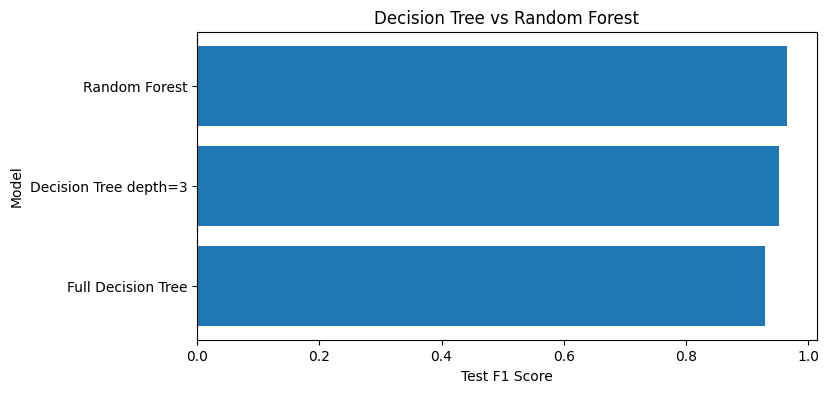

   n_estimators  train_accuracy  test_accuracy
0             1        0.971429       0.947368
1             5        0.991209       0.938596
2            10        0.995604       0.938596
3            20        1.000000       0.956140
4            50        1.000000       0.956140
5           100        1.000000       0.956140
6           200        1.000000       0.956140
7           300        1.000000       0.947368


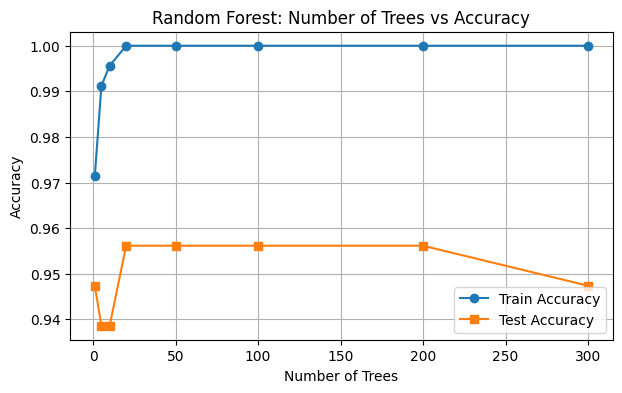

                 feature  importance
23            worst area    0.140016
27  worst concave points    0.129530
20          worst radius    0.097696
7    mean concave points    0.090885
22       worst perimeter    0.072226
2         mean perimeter    0.069574
0            mean radius    0.068676
6         mean concavity    0.057638
3              mean area    0.049172
26       worst concavity    0.034340


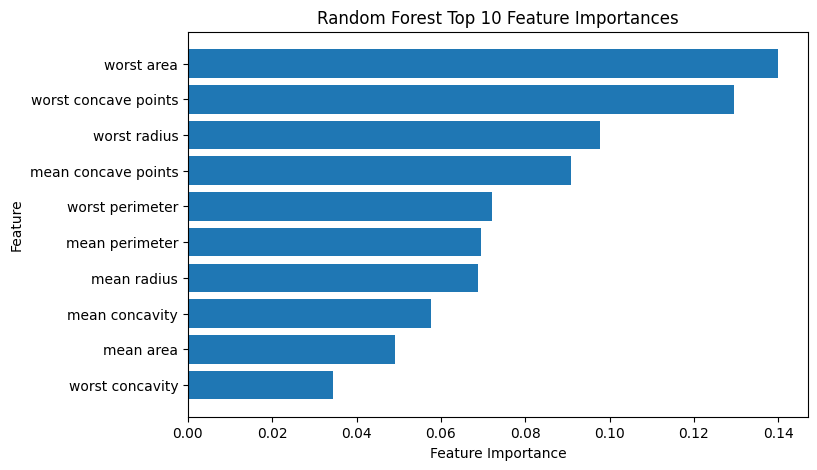

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

#1.数据读取与划分
data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names
target_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#2.先训练一个基础 Random Forest
rf = RandomForestClassifier(
    n_estimators=100, #100棵决策树
    random_state=42,
    n_jobs=-1 #尽可能使用可用 CPU 核心并行计算
)

rf.fit(X_train, y_train)

#3.预测
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

y_test_proba = rf.predict_proba(X_test)[:, 1] #benign

#4.评价模型
train_acc = accuracy_score(
    y_train,
    y_train_pred
)

test_acc = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred
)

test_recall = recall_score(
    y_test,
    y_test_pred
)

test_f1 = f1_score(
    y_test,
    y_test_pred
)

test_auc = roc_auc_score(
    y_test,
    y_test_proba
)

print("Random Forest Train Accuracy:", train_acc)
print("Random Forest Test Accuracy:", test_acc)
print("Random Forest Test Precision:", test_precision)
print("Random Forest Test Recall:", test_recall)
print("Random Forest Test F1:", test_f1)
print("Random Forest ROC AUC:", test_auc)

#5.建立模型比较表
comparison_df = pd.DataFrame([
    {
        "model": "Full Decision Tree",
        "test_accuracy": 0.9122807017543859,
        "test_f1": 0.9285714285714286,
        "test_auc": 0.9156746031746031
    },
    {
        "model": "Decision Tree depth=3",
        "test_accuracy": 0.9385964912280702,
        "test_f1": 0.9517241379310345,
        "test_auc": 0.9446097883597884
    },
    {
        "model": "Random Forest",
        "test_accuracy": test_acc,
        "test_f1": test_f1,
        "test_auc": test_auc
    }
])

print(comparison_df)

#6.可视化诊断
#从单棵树变成森林以后，当前数据上的泛化性能发生了什么？
plot_df = comparison_df.sort_values(
    "test_f1"
)

fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(
    plot_df["model"],
    plot_df["test_f1"]
)

ax.set_xlabel("Test F1 Score")
ax.set_ylabel("Model")
ax.set_title("Decision Tree vs Random Forest")

plt.show()

#第二张图：树的数量 n_estimators
n_values = [
    1, 5, 10, 20, 50,
    100, 200, 300
]

n_results = []

for n in n_values:
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    n_results.append({
        "n_estimators": n,
        "train_accuracy": accuracy_score(
            y_train,
            train_pred
        ),
        "test_accuracy": accuracy_score(
            y_test,
            test_pred
        )
    })

n_results_df = pd.DataFrame(n_results)

print(n_results_df)

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    n_results_df["n_estimators"],
    n_results_df["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

ax.plot(
    n_results_df["n_estimators"],
    n_results_df["test_accuracy"],
    marker="s",
    label="Test Accuracy"
)

ax.set_xlabel("Number of Trees")
ax.set_ylabel("Accuracy")
ax.set_title(
    "Random Forest: Number of Trees vs Accuracy"
)

ax.legend()
ax.grid(True)

plt.show()

#第三张图：Random Forest Feature Importance
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df.head(10))

top10 = importance_df.head(10).sort_values(
    "importance"
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    top10["feature"],
    top10["importance"]
)

ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")
ax.set_title(
    "Random Forest Top 10 Feature Importances"
)

plt.show()

In [8]:
#sklearn 怎么使用 OOB？
rf_oob = RandomForestClassifier(
    n_estimators=200,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf_oob.fit(X_train, y_train)

print(
    "OOB Score:",
    rf_oob.oob_score_
)

OOB Score: 0.9604395604395605


## 算法名称：随机森林  
英文名称：Random Forest  

一、适用任务  

Random Forest 可以用于分类和回归。  
本阶段重点掌握 Random Forest Classification。  

二、核心思想  

Random Forest 通过 Bootstrap 对训练样本进行有放回抽样，训练多棵决策树；同时在每个节点分裂时随机选择部分特征作为候选，从而增加不同树之间的差异性。  

最终通过综合多棵树的预测结果完成预测。  

三、Bagging 思想  

Bootstrap：  
从原训练数据中进行有放回抽样，构造不同训练子集。  

Aggregating：  
将多个基础模型的预测结果进行聚合。  

Random Forest 可以看作以 Decision Tree 为基学习器，并加入随机特征机制的 Bagging 类集成方法。  

四、两个随机性  

1. 样本随机  
每棵树通过 Bootstrap 得到不同训练样本。  

2. 特征随机  
每个节点分裂时只从随机选择的部分特征中寻找最佳切分。  

目的：  
降低树之间的相关性，提高模型多样性和稳定性。  

五、sklearn 实现  

from sklearn.ensemble import RandomForestClassifier  

model = RandomForestClassifier(  
    n_estimators=100,  
    random_state=42,  
    n_jobs=-1  
)  

model.fit(X_train, y_train)  

y_pred = model.predict(X_test)  

y_proba = model.predict_proba(  
    X_test  
)[:, 1]  

六、关键参数  

n_estimators：  
森林中决策树数量。  
增加树数量通常可以提高模型稳定性，但也会增加计算成本。  

max_depth：  
控制每棵树最大深度。  

min_samples_split：  
节点允许继续分裂所需要的最少样本数。  

min_samples_leaf：  
叶节点允许包含的最少样本数。  

max_features：  
每次节点分裂时允许考虑的特征数量，控制不同树之间的随机性。  

七、是否需要标准化  

Random Forest 通常不需要标准化。  

因为基础模型 Decision Tree 根据单个特征阈值进行划分，而不是依赖不同特征之间的距离。  

八、OOB  

Bootstrap 抽样中，没有被某棵树抽中的样本称为 Out-of-Bag samples。  

可以利用 OOB 样本对 Random Forest 进行内部评价。  

sklearn：  

RandomForestClassifier(  
    oob_score=True  
)  
  
训练后：  

model.oob_score_  

九、Feature Importance  

model.feature_importances_  

表示各特征在森林中降低节点不纯度的相对贡献。  

Feature Importance 不能解释为因果效应。  

十、优点  

1. 通常比单棵决策树泛化能力更强。  
2. 能处理非线性关系。   
3. 通常不需要标准化。  
4. 对噪声和训练样本变化通常比单树更加稳定。  
5. 可以提供 Feature Importance。  
6. 可以并行训练。  

十一、缺点  

1. 可解释性弱于单棵决策树。  
2. 树数量较多时训练和预测成本增加。  
3. 模型体积可能较大。  
4. Feature Importance 可能存在偏差。  
5. 在某些结构化数据任务上可能不如精心调优的 Boosting 模型。  

十二、比赛使用建议  
 
Random Forest 是非常重要的树模型 baseline。  

基本流程：  

数据清洗  
→ Train/Test 划分  
→ Random Forest  
→ Cross Validation  
→ 参数调优  
→ 最终测试集评价  

重点参数：  
n_estimators  
max_depth  
min_samples_split  
min_samples_leaf  
max_features  

# Day 8:GDBT梯度下降树

GBDT Train Accuracy: 1.0
GBDT Test Accuracy: 0.956140350877193
GBDT Test Precision: 0.9466666666666667
GBDT Test Recall: 0.9861111111111112
GBDT Test F1: 0.9659863945578231
GBDT ROC AUC: 0.9907407407407408
                   model  test_accuracy   test_f1  test_auc
0  Decision Tree depth=3       0.938596  0.951724  0.944610
1          Random Forest       0.956140  0.965517  0.993717
2                   GBDT       0.956140  0.965986  0.990741


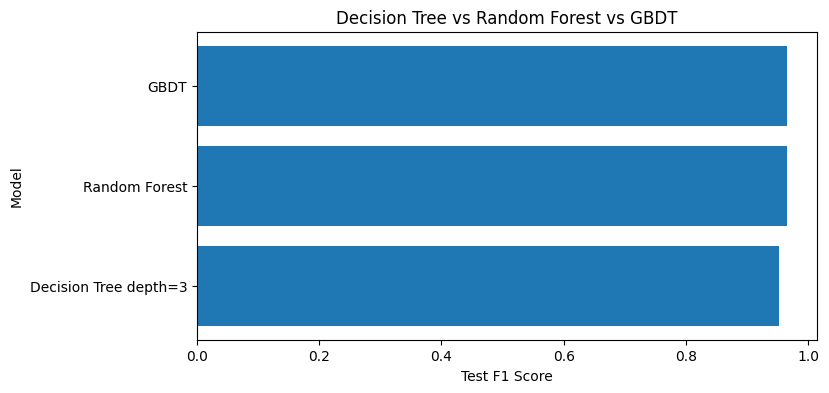

    learning_rate  n_estimators  train_accuracy  test_accuracy
0            0.01            50        0.975824       0.938596
1            0.01           100        0.986813       0.921053
2            0.01           200        0.993407       0.929825
3            0.05            50        0.993407       0.929825
4            0.05           100        1.000000       0.947368
5            0.05           200        1.000000       0.956140
6            0.10            50        1.000000       0.947368
7            0.10           100        1.000000       0.956140
8            0.10           200        1.000000       0.956140
9            0.20            50        1.000000       0.956140
10           0.20           100        1.000000       0.956140
11           0.20           200        1.000000       0.956140


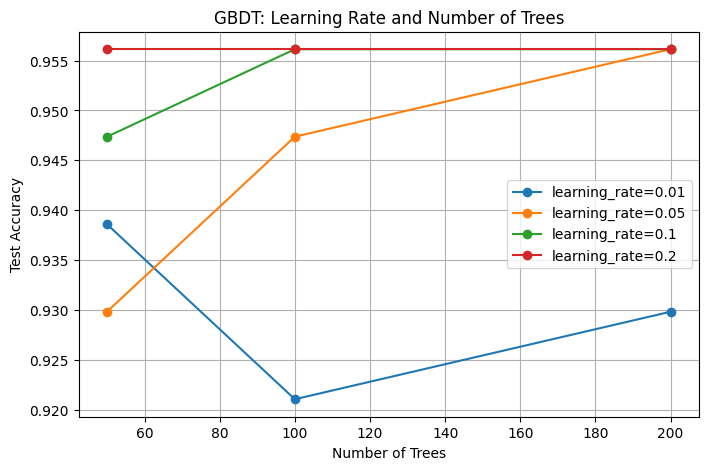

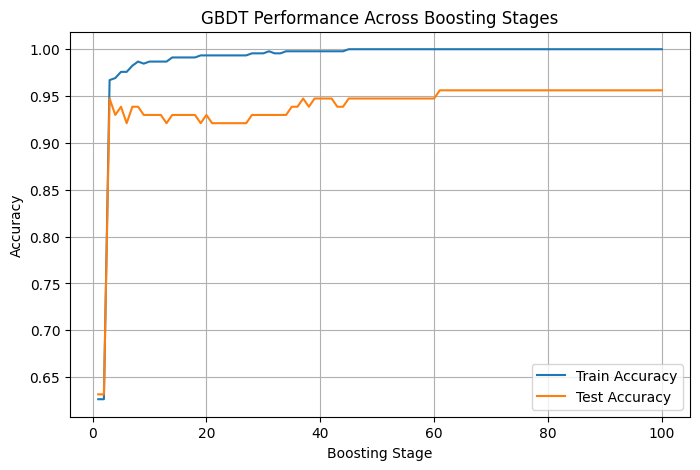

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

#1.读取数据
data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names
target_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#2.建立第一个GDBT
gbdt = GradientBoostingClassifier(
    n_estimators=100, #树的数量
    learning_rate=0.1, #学习率
    max_depth=3, #控制每一个弱学习器，也就是每一棵提升树的最大深度
    random_state=42
)

gbdt.fit(X_train, y_train)

#3.预测
y_train_pred = gbdt.predict(X_train)
y_test_pred = gbdt.predict(X_test)

y_test_proba = gbdt.predict_proba(X_test)[:, 1]

#4.评价模型
train_acc = accuracy_score(
    y_train,
    y_train_pred
)

test_acc = accuracy_score(
    y_test,
    y_test_pred
)

test_precision = precision_score(
    y_test,
    y_test_pred
)

test_recall = recall_score(
    y_test,
    y_test_pred
)

test_f1 = f1_score(
    y_test,
    y_test_pred
)

test_auc = roc_auc_score(
    y_test,
    y_test_proba
)

print("GBDT Train Accuracy:", train_acc)
print("GBDT Test Accuracy:", test_acc)
print("GBDT Test Precision:", test_precision)
print("GBDT Test Recall:", test_recall)
print("GBDT Test F1:", test_f1)
print("GBDT ROC AUC:", test_auc)

#5.可视化诊断
#Random Forest vs GBDT
comparison_df = pd.DataFrame([
    {
        "model": "Decision Tree depth=3",
        "test_accuracy": 0.9385964912280702,
        "test_f1": 0.9517241379310345,
        "test_auc": 0.9446097883597884
    },
    {
        "model": "Random Forest",
        "test_accuracy": 0.956140350877193,
        "test_f1": 0.9655172413793104,
        "test_auc": 0.9937169312169312
    },
    {
        "model": "GBDT",
        "test_accuracy": test_acc,
        "test_f1": test_f1,
        "test_auc": test_auc
    }
])

print(comparison_df)

plot_df = comparison_df.sort_values(
    "test_f1"
)

fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(
    plot_df["model"],
    plot_df["test_f1"]
)

ax.set_xlabel("Test F1 Score")
ax.set_ylabel("Model")
ax.set_title(
    "Decision Tree vs Random Forest vs GBDT"
)

plt.show()

#学习率 × 树数量
settings = [
    (0.01, 50),
    (0.01, 100),
    (0.01, 200),
    (0.05, 50),
    (0.05, 100),
    (0.05, 200),
    (0.1, 50),
    (0.1, 100),
    (0.1, 200),
    (0.2, 50),
    (0.2, 100),
    (0.2, 200)
]

results = []

for learning_rate, n_estimators in settings:

    model = GradientBoostingClassifier(
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    results.append({
        "learning_rate": learning_rate,
        "n_estimators": n_estimators,
        "train_accuracy": accuracy_score(
            y_train,
            train_pred
        ),
        "test_accuracy": accuracy_score(
            y_test,
            test_pred
        )
    })

results_df = pd.DataFrame(results)

print(results_df)

fig, ax = plt.subplots(figsize=(8, 5))

for learning_rate in sorted(
    results_df["learning_rate"].unique() #取出results_df的learning_rate并去掉重复值
):
    subset = results_df[
        results_df["learning_rate"] == learning_rate
    ]

    ax.plot(
        subset["n_estimators"],
        subset["test_accuracy"],
        marker="o",
        label=f"learning_rate={learning_rate}"
    )

ax.set_xlabel("Number of Trees")
ax.set_ylabel("Test Accuracy")
ax.set_title(
    "GBDT: Learning Rate and Number of Trees"
)

ax.legend()
ax.grid(True)

plt.show()

#真正适合 Boosting 的图————Staged Prediction
#staged_predict：观察 GBDT 在只使用前 1 棵、前 2 棵、前 3 棵……直到前 N 棵树时，模型分别会做出什么预测
#predict=只看最终成绩；staged_predict=看每一学习阶段的成绩变化
staged_train_acc = []
staged_test_acc = []

for train_pred, test_pred in zip(
    gbdt.staged_predict(X_train),
    gbdt.staged_predict(X_test)
):
    staged_train_acc.append(
        accuracy_score(
            y_train,
            train_pred
        )
    )

    staged_test_acc.append(
        accuracy_score(
            y_test,
            test_pred
        )
    )

stages = np.arange(
    1,
    len(staged_train_acc) + 1
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    stages,
    staged_train_acc,
    label="Train Accuracy"
)

ax.plot(
    stages,
    staged_test_acc,
    label="Test Accuracy"
)

ax.set_xlabel("Boosting Stage")
ax.set_ylabel("Accuracy")
ax.set_title(
    "GBDT Performance Across Boosting Stages"
)

ax.legend()
ax.grid(True)

plt.show()

## 算法名称：Gradient Boosting Decision Tree  

简称：  
GBDT  

一、适用任务  

分类与回归。  

sklearn：  
GradientBoostingClassifier  
GradientBoostingRegressor  

二、核心思想  

GBDT 使用多个决策树按照顺序逐步建立模型。  

每一轮根据当前模型的损失函数计算负梯度，并训练新的决策树拟合该负梯度，从而逐步降低整体损失。  

三、核心结构  

初始模型  
↓  
计算当前负梯度  
↓  
训练新树拟合负梯度  
↓  
learning_rate × 新树修正  
↓  
加入已有模型  
↓  
重新计算负梯度  
↓  
继续训练下一棵树  

四、平方误差回归中的特殊情况  

对于平方误差：  

负梯度 = y - prediction  

因此可以直观理解为：  

后一棵树不断拟合前面模型尚未解决的残差。  

五、模型更新  

新模型  =  旧模型  + learning_rate × 新树  

六、关键参数  

n_estimators：  
Boosting 轮数，也可以理解为加入模型的树数量。  

learning_rate：  
控制每棵新树对整体模型的贡献程度。  

max_depth：  
控制每棵弱学习器的最大深度。  

min_samples_split：  
控制节点继续分裂所需最少样本。  

min_samples_leaf：  
控制叶节点最少样本。  
  
subsample：  
每轮训练使用的样本比例。  
小于1时引入随机性。  

七、learning_rate 与 n_estimators  

两者需要联合考虑。  

较小 learning_rate：  
每轮更新较谨慎，  
通常需要更多 n_estimators。  

较大 learning_rate：  
每轮更新较大，  
可能只需要较少树，  
但也可能更容易产生不稳定或过拟合。  

八、是否需要标准化  

GBDT 基于 Decision Tree，    
通常不需要 StandardScaler。  

九、sklearn 模板  

from sklearn.ensemble import GradientBoostingClassifier  

model = GradientBoostingClassifier(  
    n_estimators=100,  
    learning_rate=0.1,  
    max_depth=3,   
    random_state=42  
)  

model.fit(X_train, y_train)  

y_pred = model.predict(X_test)  

y_proba = model.predict_proba(  
    X_test  
)[:, 1]  

十、优点  

1. 能拟合复杂非线性关系。  
2. 通常具有较强预测能力。  
3. 不需要特征标准化。  
4. 可以处理特征交互。  
5. 可以输出 Feature Importance。  

十一、缺点  

1. 树之间串行依赖，经典 GBDT 训练并行能力弱于 Random Forest。  
2. 参数之间存在明显联动。  
3. learning_rate 和 n_estimators 设置不当可能造成欠拟合或过拟合。  
4. 可解释性低于单棵 Decision Tree。  
5. 大数据场景下经典 sklearn GBDT 的训练效率并非最优。  

十二、与 Random Forest 对比  
 
Random Forest：  
Bagging  
树之间相对独立  
主要通过集成降低方差  

GBDT：  
Boosting  
树之间前后依赖  
后一轮不断改善已有模型  
通过逐步优化损失建立强模型  

十三、staged_predict总结  
  
staged_predict 用于获取 GBDT 在不同 boosting stages 下的中间预测结果，从而观察随着树数量增加，模型训练性能和验证性能如何变化。它特别适合分析模型的收敛过程、边际收益以及是否出现过拟合。


# Day 9:XGBoost

XGBoost Test Accuracy: 0.9473684210526315
XGBoost Test Precision: 0.9459459459459459
XGBoost Test Recall: 0.9722222222222222
XGBoost Test F1: 0.958904109589041
XGBoost ROC AUC: 0.9943783068783069
     model  train_accuracy  test_accuracy   test_f1  test_auc
0     GBDT             1.0       0.956140  0.965986  0.990741
1  XGBoost             1.0       0.947368  0.958904  0.994378


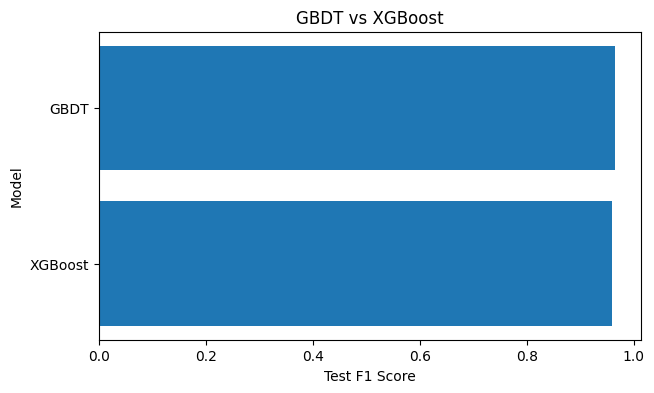

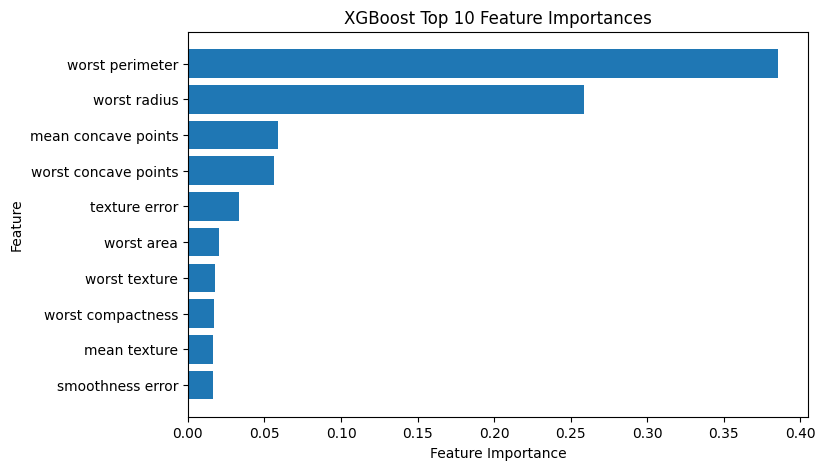

   max_depth  train_accuracy  test_accuracy
0          1        0.986813       0.956140
1          2        1.000000       0.956140
2          3        1.000000       0.947368
3          4        1.000000       0.947368
4          5        1.000000       0.947368
5          6        1.000000       0.947368
6          7        1.000000       0.947368
7          8        1.000000       0.947368


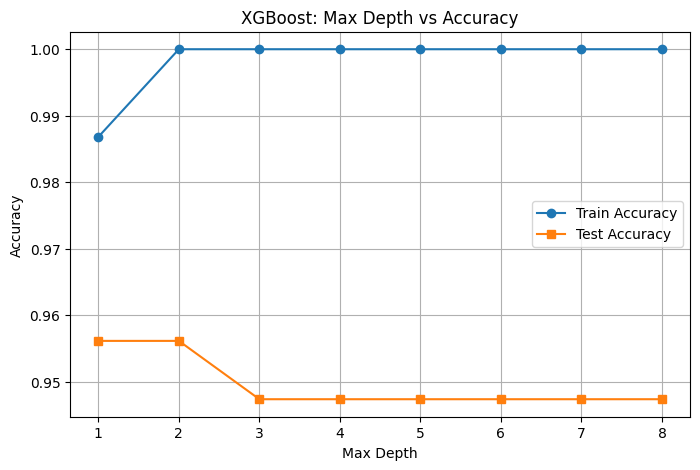

In [ ]:
import xgboost
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

#1.加载数据
data = load_breast_cancer()

X = data.data
y = data.target

#2.划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#3.创建 XGBoost 分类器
xgb_model = XGBClassifier(
    n_estimators=100, #树的数量
    learning_rate=0.1, #学习率
    max_depth=3, #树最大深度
    random_state=42,
    eval_metric="logloss"
)

#4.训练
xgb_model.fit(X_train,y_train)

#5.类别预测
y_pred = xgb_model.predict(X_test)

#6.正类概率
y_proba = xgb_model.predict_proba(X_test)[:, 1]

#7.模型评价
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_proba
)

print("XGBoost Test Accuracy:", accuracy)
print("XGBoost Test Precision:", precision)
print("XGBoost Test Recall:", recall)
print("XGBoost Test F1:", f1)
print("XGBoost ROC AUC:", auc)

#8.GBDT vs XGBoost
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier

gbdt_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gbdt_model.fit(
    X_train,
    y_train
)

models = {
    "GBDT": gbdt_model,
    "XGBoost": xgb_model
}

results = []

for name, model in models.items():

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    test_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "model": name,

        "train_accuracy":
            accuracy_score(
                y_train,
                train_pred
            ),

        "test_accuracy":
            accuracy_score(
                y_test,
                test_pred
            ),

        "test_f1":
            f1_score(
                y_test,
                test_pred
            ),

        "test_auc":
            roc_auc_score(
                y_test,
                test_proba
            )
    })


results_df = pd.DataFrame(results)

print(results_df)

#9.可视化诊断
#模型性能比较
plot_df = results_df.sort_values(by="test_f1")

fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(
    plot_df["model"],
    plot_df["test_f1"]
)
ax.set_xlabel("Test F1 Score")
ax.set_ylabel("Model")
ax.set_title( "GBDT vs XGBoost")
plt.show()

#Feature Importance
importance_df = pd.DataFrame({
    "feature": data.feature_names,
    "importance":
        xgb_model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        by="importance",
        ascending=False
    )
    .head(10)
    .sort_values(
        by="importance",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    importance_df["feature"],
    importance_df["importance"]
    )
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")
ax.set_title("XGBoost Top 10 Feature Importances")

plt.show()

#max_depth
depth_results = []

for depth in range(1, 9):

    model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=depth,
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(
        X_train,
        y_train
    )

    train_pred = model.predict(X_train)

    test_pred = model.predict(X_test)

    depth_results.append({
        "max_depth": depth,

        "train_accuracy":
            accuracy_score(
                y_train,
                train_pred
            ),

        "test_accuracy":
            accuracy_score(
                y_test,
                test_pred
            )
    })


depth_df = pd.DataFrame(depth_results)

print(depth_df)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    depth_df["max_depth"],
    depth_df["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

ax.plot(
    depth_df["max_depth"],
    depth_df["test_accuracy"],
    marker="s",
    label="Test Accuracy"
)

ax.set_xlabel( "Max Depth")
ax.set_ylabel("Accuracy")
ax.set_title("XGBoost: Max Depth vs Accuracy")
ax.legend()

ax.grid(True)

plt.show()

## 算法名称：XGBoost  
  
英文：  
Extreme Gradient Boosting  
  
所属体系：  
Gradient Boosting Tree  

一、核心思想  

按照顺序训练多棵决策树。  

每轮根据当前模型预测计算损失函数的一阶梯度和二阶梯度，建立新的树继续优化当前模型。  

最终模型由多棵 boosting trees 的贡献累加形成。  

二、与经典 GBDT 的关系    
  
共同点：  
均属于 Gradient Boosting  
树之间前后依赖  
后一棵树继续改善当前模型  
  
XGBoost 主要强化：  
一阶 + 二阶梯度  
显式复杂度正则  
分裂增益控制  
行采样  
列采样  
工程计算优化  
  
三、目标函数思想  
  
Objective=Prediction Loss+Model Complexity  
  
不仅要求预测误差小，  
还要限制模型复杂度。  
  
四、核心参数  
  
n_estimators：  
Boosting 树数量。  
  
learning_rate：  
每棵新树对整体模型的贡献程度。  
  
max_depth：  
每一棵 boosting tree 的最大深度。  
  
gamma：  
一次节点分裂所需的最低收益门槛。  
越大通常越保守。  
  
subsample：  
每轮使用的训练样本比例。  
  
colsample_bytree：  
每棵树使用的特征比例。  
  
reg_alpha：  
L1 正则化。  
  
reg_lambda：  
L2 正则化。  
  
五、sklearn 风格代码  
  
from xgboost import XGBClassifier  
  
model = XGBClassifier(  
    n_estimators=100,  
    learning_rate=0.1,  
    max_depth=3,  
    random_state=42,  
    eval_metric="logloss"  
)  
  
model.fit(X_train, y_train)  
  
y_pred = model.predict(X_test)  
  
y_proba = model.predict_proba(X_test)[:, 1]  
  
六、是否需要标准化  
  
通常不需要。  
  
XGBoost 基于 Decision Tree 的阈值切分，  
不依赖欧氏距离和变量绝对尺度。  
  
七、优点  
  
预测能力通常较强。  
能处理复杂非线性关系。  
包含系统正则化机制。  
支持行、列采样。  
无需标准化。  
结构化表格数据中非常常用。  
  
八、缺点  
  
参数较多且存在联动。  
错误调参可能过拟合。  
解释性弱于单棵树和线性模型。  
相较简单模型训练成本更高。  
不能因为算法强就假设一定优于其他模型。  
  
九、比赛原则  
  
建立 baseline  
↓  
使用 CV 比较模型  
↓  
调 learning_rate + n_estimators    
↓    
调 max_depth 等树结构参数  
↓  
调 subsample / colsample  
↓  
调正则化参数  
↓  
最终训练  
↓  
独立测试 / 提交  

# Day 10: SVC 支持向量分类

X shape: (569, 30)
y shape: (569,)
Target names: ['malignant' 'benign']
SVC Test Accuracy: 0.9824561403508771
SVC Test Precision: 0.9861111111111112
SVC Test Recall: 0.9861111111111112
SVC Test F1: 0.9861111111111112
SVC ROC AUC: 0.9950396825396826
Number of support vectors: [51 46]
Total support vectors: 97
        C  train_accuracy  test_accuracy
0    0.01        0.626374       0.631579
1    0.10        0.958242       0.947368
2    1.00        0.982418       0.982456
3   10.00        0.993407       0.973684
4  100.00        1.000000       0.947368


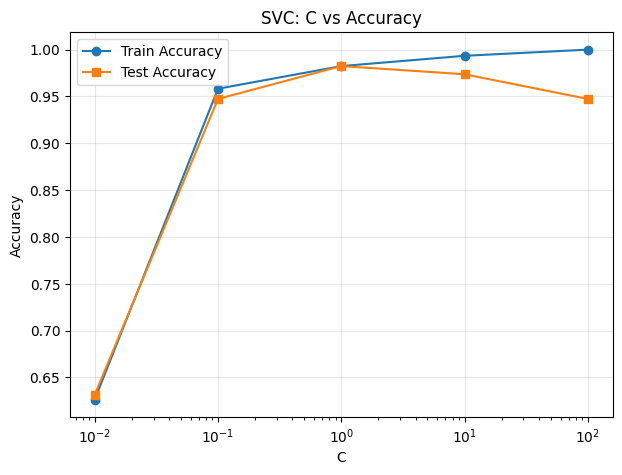

    gamma  train_accuracy  test_accuracy
0   0.001        0.951648       0.956140
1   0.010        0.982418       0.982456
2   0.100        0.989011       0.956140
3   1.000        1.000000       0.631579
4  10.000        1.000000       0.631579


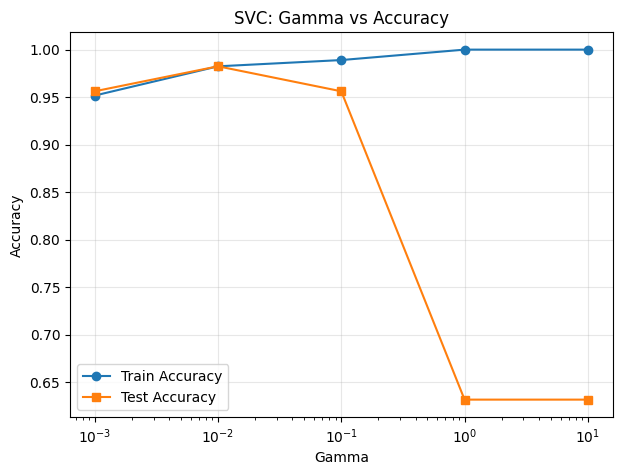

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve

# 1. 读取数据
data = load_breast_cancer()

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target names:", data.target_names)

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. 标准化
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. 建立 SVC
svc = SVC( #Support Vector Classification 支持向量分类
    kernel="rbf", #高斯核
    C=1.0, #违反间隔/错分的惩罚强度，c越大，惩罚强度越大，容易过拟合
    gamma="scale", #控制RBF Kernel 中单个样本影响范围，gamma越大，影响范围越局限，容易过拟合
    probability=True, #开启概率估计
    random_state=42
)

# 5. 训练
svc.fit(X_train_scaled, y_train)

# 6. 预测
y_pred = svc.predict(X_test_scaled)
y_proba = svc.predict_proba(X_test_scaled)[:, 1]

# 7. 模型评价
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("SVC Test Accuracy:", accuracy)
print("SVC Test Precision:", precision)
print("SVC Test Recall:", recall)
print("SVC Test F1:", f1)
print("SVC ROC AUC:", auc)

print("Number of support vectors:", svc.n_support_)
print("Total support vectors:", svc.support_vectors_.shape[0])

#8.可视化诊断
#C 对模型性能的影响
C_values = [0.01, 0.1, 1, 10, 100]

c_results = []

for C in C_values:
    model = SVC(kernel="rbf", C=C, gamma="scale")
    model.fit(X_train_scaled, y_train)

    train_accuracy = model.score(X_train_scaled, y_train)
    test_accuracy = model.score(X_test_scaled, y_test)

    c_results.append({
        "C": C,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy
    })

c_df = pd.DataFrame(c_results)

print(c_df)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(c_df["C"], c_df["train_accuracy"], marker="o", label="Train Accuracy")
ax.plot(c_df["C"], c_df["test_accuracy"], marker="s", label="Test Accuracy")

ax.set_xscale("log")
ax.set_xlabel("C")
ax.set_ylabel("Accuracy")
ax.set_title("SVC: C vs Accuracy")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

#gamma对模型性能的影响
gamma_values = [0.001, 0.01, 0.1, 1, 10]

gamma_results = []

for gamma in gamma_values:
    model = SVC(kernel="rbf", C=1.0, gamma=gamma)
    model.fit(X_train_scaled, y_train)

    train_accuracy = model.score(X_train_scaled, y_train)
    test_accuracy = model.score(X_test_scaled, y_test)

    gamma_results.append({
        "gamma": gamma,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy
    })

gamma_df = pd.DataFrame(gamma_results)

print(gamma_df)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(gamma_df["gamma"], gamma_df["train_accuracy"], marker="o", label="Train Accuracy")
ax.plot(gamma_df["gamma"], gamma_df["test_accuracy"], marker="s", label="Test Accuracy")

ax.set_xscale("log")
ax.set_xlabel("Gamma")
ax.set_ylabel("Accuracy")
ax.set_title("SVC: Gamma vs Accuracy")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

## 算法名称：Support Vector Machine  
  
分类实现：  
SVC  
  
一、核心思想  
  
寻找能够区分类别的分类超平面，  
并最大化分类边界与最近样本之间的 Margin。  
  
二、Support Vector  
  
距离决策边界最近、  
位于或违反 Margin 的关键训练样本。  
  
这些样本对最终分类边界的位置起决定作用。  
  
三、Hard Margin  
  
要求训练样本完全正确分类，  
同时最大化 Margin。  
   
适合严格线性可分数据，  
现实中应用有限。  
  
四、Soft Margin  
   
允许部分样本违反 Margin 或被错分，  
在训练误差与模型复杂度之间进行权衡。  
  
五、核心参数 C  
  
C 控制错分和违反 Margin 的惩罚。  
  
C 小：  
容忍更多错误  
正则化更强  
Margin 通常更宽  
可能欠拟合  
  
C 大：  
错误惩罚更强  
更努力拟合训练数据  
正则化更弱  
可能过拟合  
  
六、Kernel Trick  
   
用于处理非线性可分问题。  
  
通过核函数隐式计算高维空间内积，  
无需显式构造全部高维特征。  
  
七、RBF Kernel  
  
K(x_i,x_j) = exp(-gamma ||x_i-x_j||²)  
  
gamma 小：  
影响范围较大  
决策边界较平滑  
可能欠拟合  
  
gamma 大：  
影响范围较小  
决策边界更加局部和复杂  
可能过拟合  
  
八、标准化  
  
SVC 对特征尺度敏感。  
  
通常使用：  
  
StandardScaler  
↓  
SVC  
  
九、sklearn 代码  
  
from sklearn.preprocessing import StandardScaler  
from sklearn.svm import SVC  
  
scaler = StandardScaler()  
  
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)  
  
model = SVC(  
    kernel="rbf",  
    C=1.0,  
    gamma="scale",  
    probability=True,  
    random_state=42  
)  
  
model.fit(X_train_scaled, y_train)  
  
y_pred = model.predict(X_test_scaled)  
y_proba = model.predict_proba(X_test_scaled)[:, 1]  
  
十、fit 背后的算法过程  
  
标准化训练样本   
↓  
选择 Kernel  
↓  
根据 C 构造软间隔优化问题  
↓  
寻找支持向量  
↓  
求解最大间隔分类边界  
↓  
保存支持向量与模型参数  
  
十一、常用评价指标  
  
Accuracy  
Precision  
Recall  
F1  
ROC AUC  
Confusion Matrix  
  
十二、主要调参  
  
C  
gamma  
kernel  
  
正式比赛通过 Cross Validation 联合选择。  
  
十三、优点  
  
最大间隔具有较强理论基础。  
适合中小样本。   
支持非线性分类。  
在高维数据中常有较好表现。   
决策边界由部分支持向量决定。  
  
十四、缺点  
  
对尺度敏感。  
大样本训练成本较高。  
C 和 gamma 较敏感。  
核模型解释性较弱。  
概率估计会增加计算成本。  
  
十五、比赛使用建议  
  
标准化  
↓  
SVC baseline  
↓  
CV 调 C / gamma / kernel  
↓  
比较 F1 / AUC 等指标  
↓  
与树模型公平比较  

# Day 11:SVR支持向量回归

X shape: (442, 10)
y shape: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
SVR Train RMSE: 44.91344142739
SVR Test RMSE: 51.06409981767857
SVR Train MAE: 29.620236090004756
SVR Test MAE: 39.418657722157796
SVR Train R2: 0.6680241787089961
SVR Test R2: 0.5078392590548372
Number of support vectors: 353


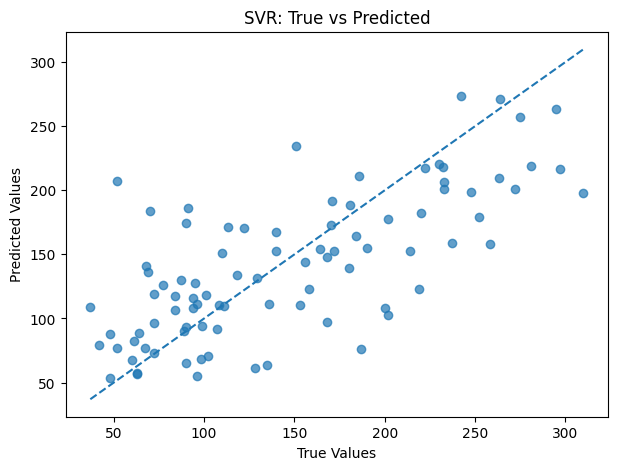

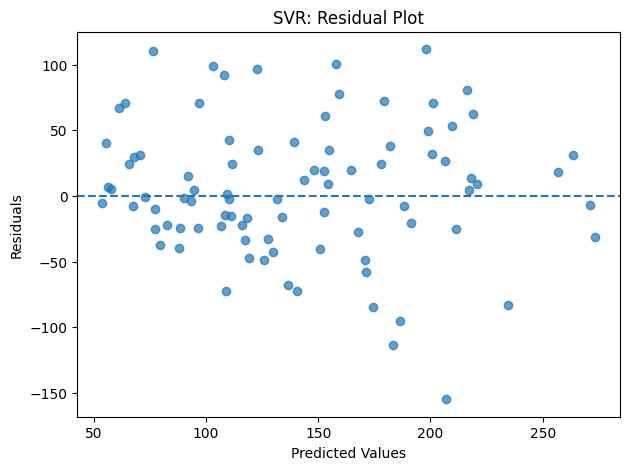

      C  train_rmse  test_rmse
0     1   71.146423  65.823540
1    10   53.197017  51.791775
2   100   44.913441  51.064100
3  1000   31.830434  65.927800


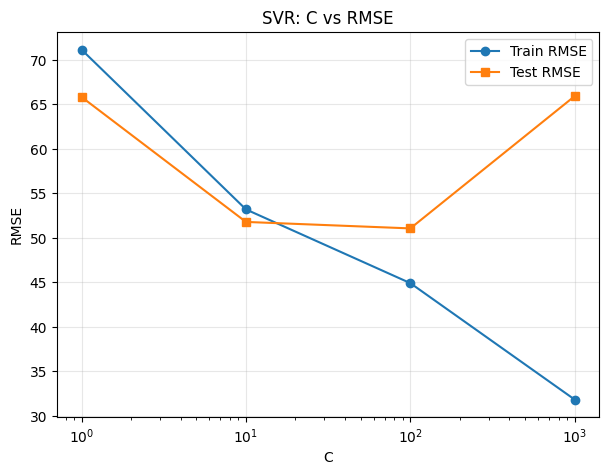

   epsilon  train_rmse  test_rmse  n_support
0      0.1   44.913441  51.064100        353
1      1.0   44.889580  51.055978        345
2      5.0   44.687450  50.963909        322
3     10.0   44.700760  51.462322        299
4     20.0   45.065250  53.101868        250


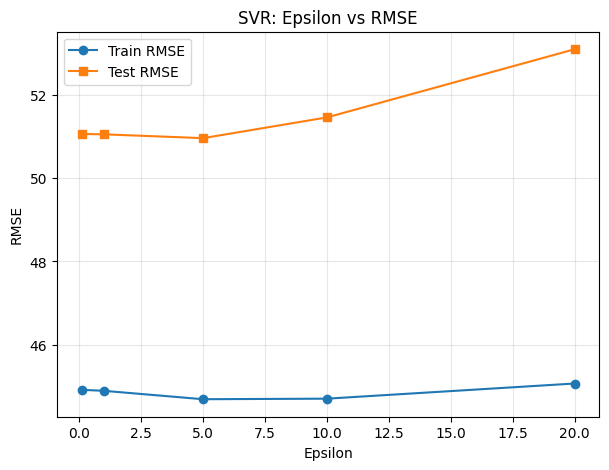

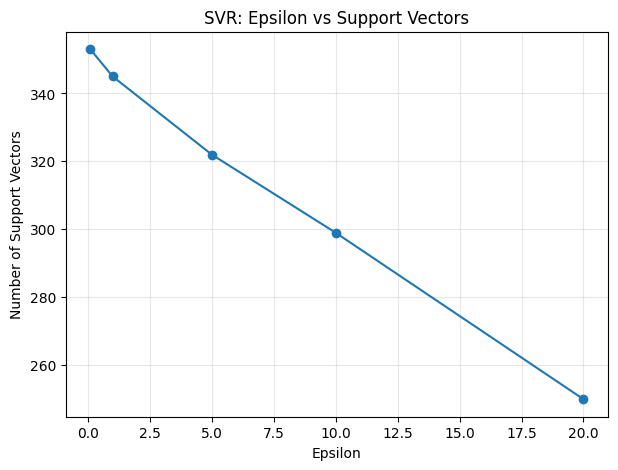

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# 1. 读取数据
data = load_diabetes()

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature names:", data.feature_names)

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 3. 标准化特征
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. 建立 SVR 模型
svr = SVR(
    kernel="rbf",
    C=100, #C 定义“越界之后的处罚强度”
    epsilon=0.1, #epsilon 定义“容忍区间”
    gamma="scale"
)

# 5. 训练模型
svr.fit(X_train_scaled, y_train)

# 6. 预测
y_train_pred = svr.predict(X_train_scaled)
y_test_pred = svr.predict(X_test_scaled)

# 7. 评价模型
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("SVR Train RMSE:", train_rmse)
print("SVR Test RMSE:", test_rmse)
print("SVR Train MAE:", train_mae)
print("SVR Test MAE:", test_mae)
print("SVR Train R2:", train_r2)
print("SVR Test R2:", test_r2)

print("Number of support vectors:", len(svr.support_))

#8.可视化诊断
#True vs Predicted
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(y_test, y_test_pred, alpha=0.7)

min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

ax.set_xlabel("True Values")
ax.set_ylabel("Predicted Values")
ax.set_title("SVR: True vs Predicted")

plt.show()

#Residual plot
residuals = y_test - y_test_pred

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(y_test_pred, residuals, alpha=0.7)

ax.axhline(
    y=0,
    linestyle="--"
)

ax.set_xlabel("Predicted Values")
ax.set_ylabel("Residuals")
ax.set_title("SVR: Residual Plot")

plt.show()

#C vs RMSE
C_values = [1, 10, 100, 1000]

c_results = []

for C in C_values:
    model = SVR(
        kernel="rbf",
        C=C,
        epsilon=0.1,
        gamma="scale"
    )

    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    c_results.append({
        "C": C,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse
    })

c_df = pd.DataFrame(c_results)

print(c_df)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(c_df["C"], c_df["train_rmse"], marker="o", label="Train RMSE")
ax.plot(c_df["C"], c_df["test_rmse"], marker="s", label="Test RMSE")

ax.set_xscale("log")
ax.set_xlabel("C")
ax.set_ylabel("RMSE")
ax.set_title("SVR: C vs RMSE")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

#epsilon vs RMSE + Support Vectors
epsilon_values = [0.1, 1, 5, 10, 20]

epsilon_results = []

for epsilon in epsilon_values:
    model = SVR(
        kernel="rbf",
        C=100,
        epsilon=epsilon,
        gamma="scale"
    )

    model.fit(X_train_scaled, y_train)

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    epsilon_results.append({
        "epsilon": epsilon,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "n_support": len(model.support_)
    })

epsilon_df = pd.DataFrame(epsilon_results)

print(epsilon_df)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    epsilon_df["epsilon"],
    epsilon_df["train_rmse"],
    marker="o",
    label="Train RMSE"
)

ax.plot(
    epsilon_df["epsilon"],
    epsilon_df["test_rmse"],
    marker="s",
    label="Test RMSE"
)

ax.set_xlabel("Epsilon")
ax.set_ylabel("RMSE")
ax.set_title("SVR: Epsilon vs RMSE")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    epsilon_df["epsilon"],
    epsilon_df["n_support"],
    marker="o"
)

ax.set_xlabel("Epsilon")
ax.set_ylabel("Number of Support Vectors")
ax.set_title("SVR: Epsilon vs Support Vectors")
ax.grid(alpha=0.3)

plt.show()

## 算法名称：Support Vector Regression  
  
简称：  
SVR  

一、核心思想  

在回归函数周围建立 ε-insensitive tube。  

当：  
|y - prediction| <= epsilon  

损失为 0。  

只有超过 epsilon 的部分才受到惩罚。  

二、关键参数  

epsilon：  
决定多大的预测误差可以忽略。  

epsilon 大：  
tube 更宽  
容忍更多误差  
支持向量通常减少  
模型更简单  
可能欠拟合  

epsilon 小： 
tube 更窄  
更多样本参与损失  
支持向量通常增加  
模型更复杂  

C：  
决定超过 epsilon 后处罚多重。  

C 大：  
更严格拟合训练集  
正则化较弱  
过拟合风险增加  

C 小：  
更宽容  
正则化较强  
可能欠拟合  

gamma：  
RBF 核参数。  

gamma 大：  
单点影响范围小  
模型更局部、更复杂  
可能过拟合  

gamma 小：  
函数更平滑  
可能欠拟合  

三、标准化  

RBF-SVR 对 X 尺度敏感，  
通常需要 StandardScaler。  

y 的尺度也值得关注，  
尤其会影响 epsilon 的实际含义。  

工程上可进一步使用：  
TransformedTargetRegressor  

四、sklearn 基础代码  

from sklearn.preprocessing import StandardScaler  
from sklearn.svm import SVR  

scaler = StandardScaler()  

X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)  

model = SVR(  
    kernel="rbf",  
    C=100,  
    epsilon=0.1,  
    gamma="scale"  
)  

model.fit(X_train_scaled, y_train)  

y_pred = model.predict(X_test_scaled)  

五、fit 背后的算法流程  
  
标准化 X  
↓  
选择核函数  
↓  
建立回归函数  
↓  
构造 ε-tube    
↓  
tube 内误差不处罚  
↓  
tube 外误差按 C 处罚  
↓  
控制函数复杂度  
↓  
确定支持向量  
↓  
得到最终回归函数  

六、常用评价指标  

RMSE  
MAE  
R²  

七、关键诊断  

True vs Predicted  
Residual Plot  
C vs RMSE  
epsilon vs RMSE  
epsilon vs Support Vectors  

八、优点  

可处理非线性回归  
适合中小样本  
具有明确的正则化思想  
支持核技巧  
可形成稀疏支持向量表示  

九、缺点  

对尺度敏感  
参数 C / epsilon / gamma 较敏感  
大规模数据训练成本较高  
解释性较弱  
目标变量尺度会影响 epsilon 含义  

十、比赛使用建议  

StandardScaler  
↓  
SVR baseline  
↓  
Cross Validation  
↓  
联合调 C / epsilon / gamma  
↓  
与线性模型和树模型比较  

# Day 12：LightGBM

X shape: (569, 30)
y shape: (569,)
Target names: ['malignant' 'benign']
LightGBM Train Accuracy: 1.0
LightGBM Test Accuracy: 0.9649122807017544
LightGBM Test Precision: 0.9594594594594594
LightGBM Test Recall: 0.9861111111111112
LightGBM Test F1: 0.9726027397260274
LightGBM ROC AUC: 0.9900793650793651
      model  test_accuracy   test_f1  test_auc
0      GBDT       0.956140  0.965986  0.990741
1   XGBoost       0.947368  0.958904  0.994378
2  LightGBM       0.964912  0.972603  0.990079


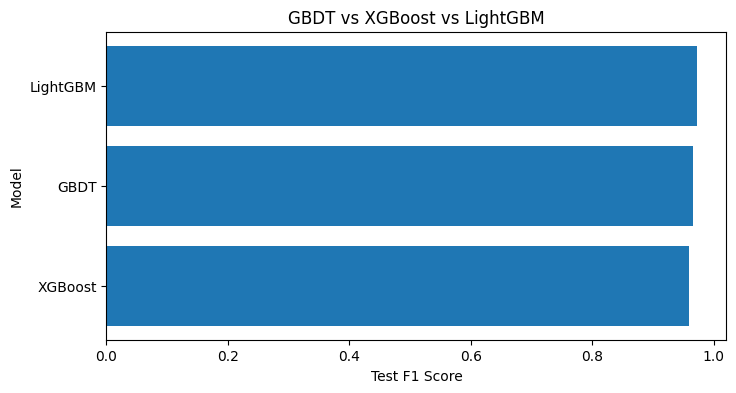

   num_leaves  train_accuracy  test_accuracy
0           3        0.989011       0.956140
1           7        1.000000       0.956140
2          15        1.000000       0.964912
3          31        1.000000       0.956140
4          63        1.000000       0.956140


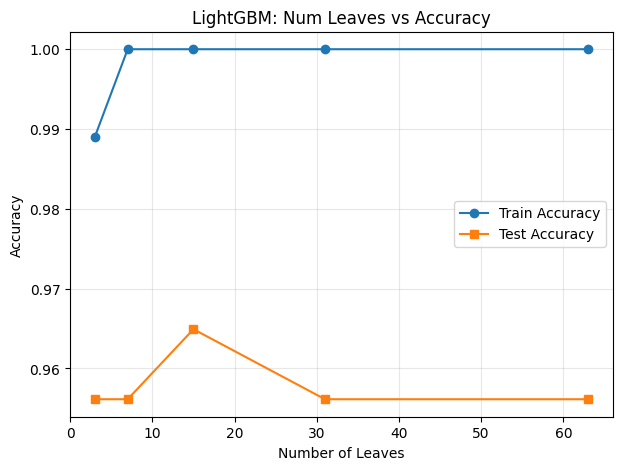

   min_child_samples  train_accuracy  test_accuracy
0                  5        1.000000       0.929825
1                 10        1.000000       0.947368
2                 20        1.000000       0.956140
3                 40        0.997802       0.956140
4                 80        0.989011       0.947368


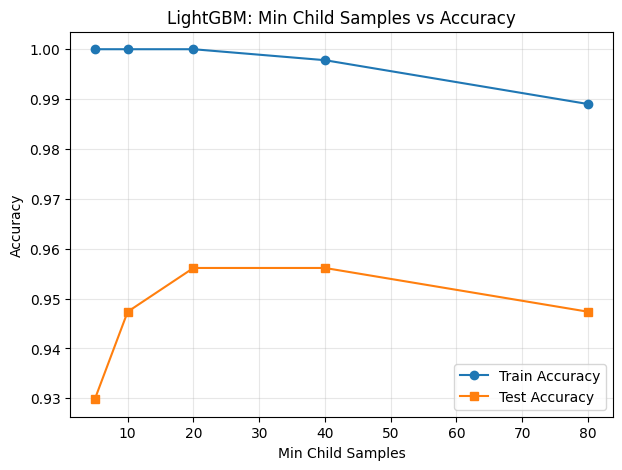

                 feature  importance
21         worst texture         165
27  worst concave points         163
22       worst perimeter          89
13            area error          86
1           mean texture          86
28        worst symmetry          84
23            worst area          83
20          worst radius          72
24      worst smoothness          61
7    mean concave points          52


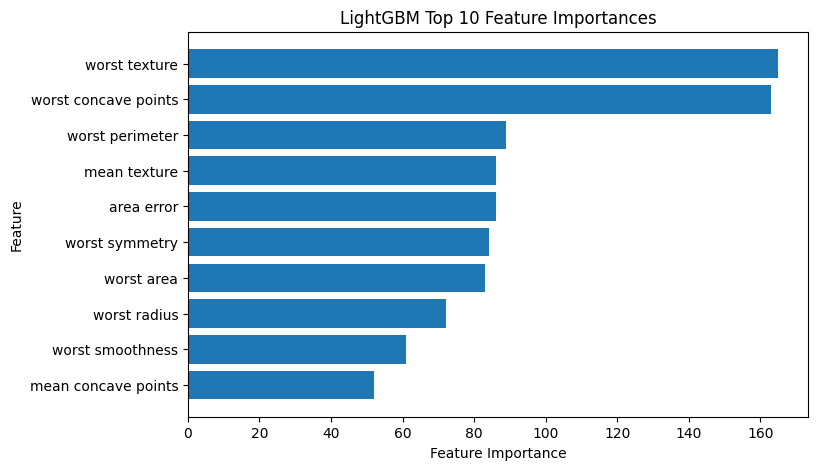

                 feature  split         gain  gain_normalized
22       worst perimeter     89  1639.807541         0.271512
27  worst concave points    163  1193.337667         0.197587
20          worst radius     72  1175.630147         0.194655
7    mean concave points     52   691.763307         0.114539
23            worst area     83   420.558380         0.069634
21         worst texture    165   226.514765         0.037505
1           mean texture     86   171.939964         0.028469
13            area error     86    83.073646         0.013755
26       worst concavity     43    71.524069         0.011843
24      worst smoothness     61    69.657998         0.011534


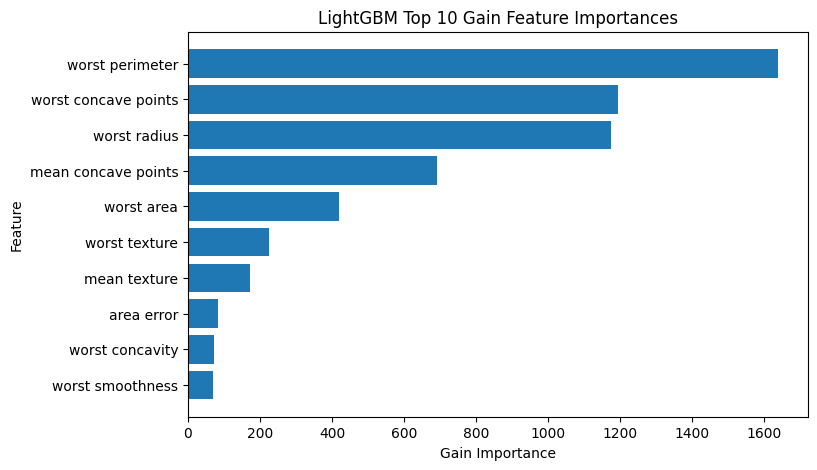

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 1. 读取数据
data = load_breast_cancer()

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target names:", data.target_names)

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. 创建 LightGBM 分类模型
lgbm = LGBMClassifier(
    n_estimators=100, #100 个 boosting stages
    learning_rate=0.05,
    num_leaves=15, #一棵树最多多少叶子
    max_depth=-1, #一条路径最多多深
    min_child_samples=20, #一个叶子至少多少样本，越小越容易过拟合
    random_state=42,
    verbosity=-1 #减少训练过程打印的信息
)

# 4. 训练模型
lgbm.fit(X_train, y_train)

# 5. 预测
y_train_pred = lgbm.predict(X_train)
y_test_pred = lgbm.predict(X_test)

y_test_proba = lgbm.predict_proba(X_test)[:, 1]

# 6. 评价
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
auc = roc_auc_score(y_test, y_test_proba)

print("LightGBM Train Accuracy:", train_accuracy)
print("LightGBM Test Accuracy:", test_accuracy)
print("LightGBM Test Precision:", precision)
print("LightGBM Test Recall:", recall)
print("LightGBM Test F1:", f1)
print("LightGBM ROC AUC:", auc)

#可视化诊断
#GBDT vs XGBoost vs LightGBM
comparison_df = pd.DataFrame([
    {
        "model": "GBDT",
        "test_accuracy": 0.956140350877193,
        "test_f1": 0.9659863945578231,
        "test_auc": 0.9907407407407408
    },
    {
        "model": "XGBoost",
        "test_accuracy": 0.9473684210526315,
        "test_f1": 0.958904109589041,
        "test_auc": 0.9943783068783069
    },
    {
        "model": "LightGBM",
        "test_accuracy": test_accuracy,
        "test_f1": f1,
        "test_auc": auc
    }
])

print(comparison_df)

plot_df = comparison_df.sort_values("test_f1")

fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(plot_df["model"], plot_df["test_f1"])

ax.set_xlabel("Test F1 Score")
ax.set_ylabel("Model")
ax.set_title("GBDT vs XGBoost vs LightGBM")

plt.show()

#num_leaves
leaf_values = [3, 7, 15, 31, 63]

leaf_results = []

for num_leaves in leaf_values:
    model = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        num_leaves=num_leaves,
        min_child_samples=20,
        random_state=42,
        verbosity=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    leaf_results.append({
        "num_leaves": num_leaves,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred)
    })

leaf_df = pd.DataFrame(leaf_results)

print(leaf_df)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    leaf_df["num_leaves"],
    leaf_df["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

ax.plot(
    leaf_df["num_leaves"],
    leaf_df["test_accuracy"],
    marker="s",
    label="Test Accuracy"
)

ax.set_xlabel("Number of Leaves")
ax.set_ylabel("Accuracy")
ax.set_title("LightGBM: Num Leaves vs Accuracy")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

#min_child_samples
min_child_values = [5, 10, 20, 40, 80]

child_results = []

for min_child_samples in min_child_values:
    model = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=min_child_samples,
        random_state=42,
        verbosity=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    child_results.append({
        "min_child_samples": min_child_samples,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred)
    })

child_df = pd.DataFrame(child_results)

print(child_df)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    child_df["min_child_samples"],
    child_df["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

ax.plot(
    child_df["min_child_samples"],
    child_df["test_accuracy"],
    marker="s",
    label="Test Accuracy"
)

ax.set_xlabel("Min Child Samples")
ax.set_ylabel("Accuracy")
ax.set_title("LightGBM: Min Child Samples vs Accuracy")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

#Feature Importance
importance_df = pd.DataFrame({
    "feature": data.feature_names,
    "importance": lgbm.feature_importances_
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df.head(10))

top10 = importance_df.head(10).sort_values("importance")

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(top10["feature"], top10["importance"])

ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")
ax.set_title("LightGBM Top 10 Feature Importances")

plt.show()

#split vs gain
split_importance = lgbm.booster_.feature_importance(importance_type="split")
gain_importance = lgbm.booster_.feature_importance(importance_type="gain")

importance_compare_df = pd.DataFrame({
    "feature": data.feature_names,
    "split": split_importance,
    "gain": gain_importance
})

importance_compare_df["gain_normalized"] = (
    importance_compare_df["gain"] /
    importance_compare_df["gain"].sum()
)

print(
    importance_compare_df
    .sort_values("gain", ascending=False)
    .head(10)
)

gain_df = importance_compare_df.sort_values("gain", ascending=False).head(10)
gain_df = gain_df.sort_values("gain")

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(gain_df["feature"], gain_df["gain"])

ax.set_xlabel("Gain Importance")
ax.set_ylabel("Feature")
ax.set_title("LightGBM Top 10 Gain Feature Importances")

plt.show()

## 算法名称：LightGBM

全称：  
Light Gradient Boosting Machine  

所属体系：  
Gradient Boosting Decision Tree  

一、核心思想  

Boosting：  
后一棵树持续改善已有模型。  

LightGBM 重点优化：  
Histogram  
+
Leaf-wise / Best-first  
+
高效数据处理  

二、Histogram  

连续特征    
↓   
离散为有限 bins    
↓  
基于 bin 统计寻找切分  

作用：  
减少切分候选  
降低计算成本  
降低存储成本  
可能带来一定正则化效果  

三、Leaf-wise  

当前所有叶节点中：  

寻找能够带来最大 Loss reduction 的叶节点    
↓  
优先继续分裂  

优点：  
有限复杂度下更有效降低 Loss  
  
风险：  
局部树枝可能过深  
小样本容易过拟合  

四、核心复杂度参数  

num_leaves：  
每棵树最大叶节点数。  
↑    
→ 模型更复杂  

min_child_samples：    
叶节点至少包含的训练样本数。  
↑  
→ 模型更保守  
→ 抑制过拟合  

max_depth：  
限制单条路径最大深度。  

五、Boosting 参数  

n_estimators：  
Boosting 轮数。  

learning_rate：  
每棵新树对整体模型的贡献。  

通常联合调节。  

六、随机采样  

bagging_fraction：  
抽取部分样本。  

feature_fraction：  
抽取部分 features。  

作用：  
增加随机性  
缓解过拟合  

七、正则化  

reg_alpha：  
L1  

reg_lambda：  
L2  

八、是否需要标准化  

通常不需要。  

LightGBM 基于树的阈值划分，  
并不依赖欧氏距离。  

九、sklearn 风格基础代码  

from lightgbm import LGBMClassifier  

model = LGBMClassifier(  
    n_estimators=100,  
    learning_rate=0.05,  
    num_leaves=15,  
    min_child_samples=20,  
    random_state=42,  
    verbosity=-1  
)  

model.fit(X_train, y_train)  

y_pred = model.predict(X_test)  
y_proba = model.predict_proba(X_test)[:, 1]  

十、fit 背后的流程  

输入训练数据  
↓  
Histogram 分箱  
↓  
建立 Boosting 初始预测  
↓  
计算梯度信息  
↓  
评价候选叶节点分裂收益  
↓  
选择 Gain 最大的叶节点  
↓  
Leaf-wise 分裂  
↓  
受到 num_leaves /  
min_child_samples 等约束  
↓  
形成当前树  
↓  
learning_rate × 当前树  
↓  
加入整体模型  
↓  
继续下一轮 Boosting  

十一、Feature Importance  

split：  
特征被用于切分的次数。  

gain：  
特征所有切分累计带来的 Loss reduction。  

split 高  
≠  
gain 一定高。  

Feature Importance  
≠  
因果效应。  

十二、主要优点  

结构化表格数据预测能力强  
训练效率较高  
内存利用效率高  
能够处理复杂非线性和特征交互  
通常无需标准化  
参数与随机采样机制丰富  

十三、主要缺点  

Leaf-wise 在小样本上容易过拟合  
参数较多且存在联动  
解释性弱于线性模型和单棵树  
内置 Feature Importance 存在局限  
模型强并不代表一定优于 XGBoost / CatBoost  

十四、比赛使用原则  

LightGBM baseline  
↓  
CV  
↓  
重点调：  
num_leaves  
min_child_samples  
learning_rate  
n_estimators  
↓  
再考虑：  
bagging_fraction  
feature_fraction  
reg_alpha  
reg_lambda  
↓  
与 XGBoost / CatBoost / GBDT 比较  
↓  
最终模型  

# Day13:CatBoost

CatBoost Train Accuracy: 0.8775
CatBoost Test Accuracy: 0.795
CatBoost Test Precision: 0.8395061728395061
CatBoost Test Recall: 0.9006622516556292
CatBoost Test F1: 0.8690095846645367
CatBoost ROC AUC: 0.8440329774293823
   depth  train_accuracy  test_accuracy
0      3         0.84875          0.795
1      4         0.85125          0.805
2      5         0.86500          0.790
3      6         0.87750          0.795
4      8         0.88250          0.785
5     10         0.90500          0.790


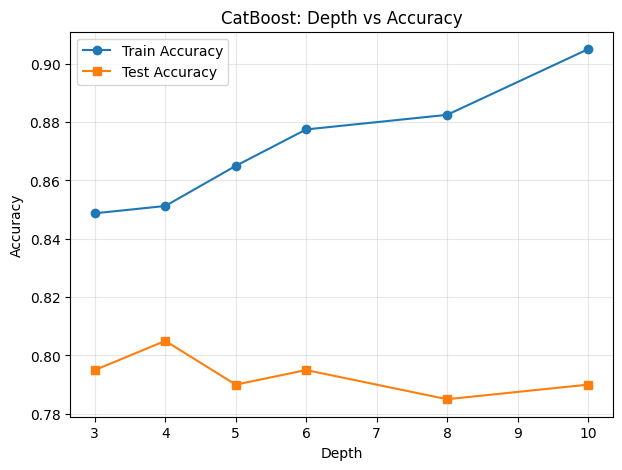

   l2_leaf_reg  train_accuracy  test_accuracy
0            1         0.87875          0.805
1            3         0.87750          0.795
2            5         0.86875          0.815
3           10         0.86125          0.790
4           30         0.85500          0.795


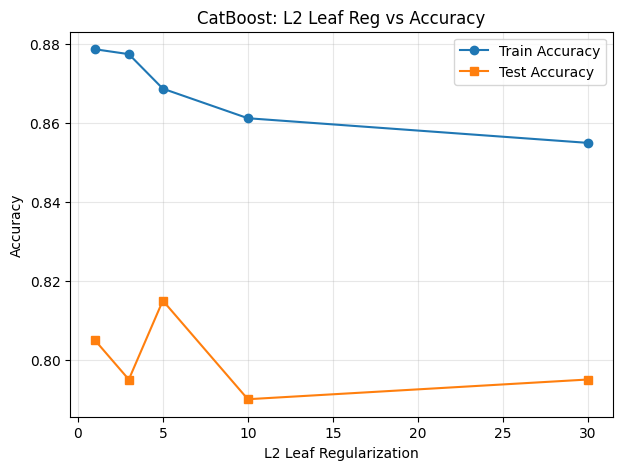

        feature  importance
0           age   30.942544
1        income   26.935528
2          city   16.757957
4  member_level   16.657336
3        device    8.706634


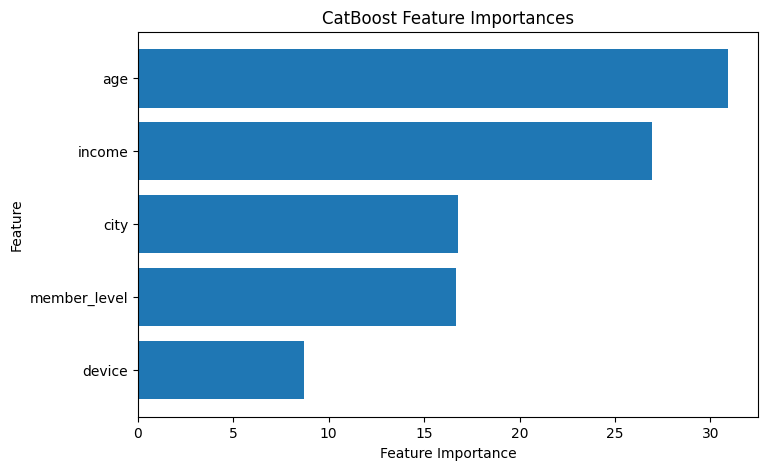

In [19]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

#1.构造教学数据
np.random.seed(42)

n = 1000

df = pd.DataFrame({
    "age": np.random.randint(18, 70, size=n), #age，income为数值特征
    "income": np.random.normal(8000, 2500, size=n), #正态分布，normal(均值,标准差,数量)
    "city": np.random.choice( #city，device，member_level为类别特征
        ["Beijing", "Shanghai", "Guangzhou", "Shenzhen"],
        size=n
    ),
    "device": np.random.choice(
        ["Android", "iPhone"],
        size=n
    ),
    "member_level": np.random.choice(
        ["Bronze", "Silver", "Gold"],
        size=n
    )
})

#2.创建一个目标变量，让city、device、member_level和target存在关系
score = (
    0.04 * (df["age"] - 40)
    + 0.00025 * (df["income"] - 8000)
    + 0.8 * (df["device"] == "iPhone").astype(int)
    + 1.0 * (df["member_level"] == "Gold").astype(int)
    + 0.6 * (df["city"] == "Shanghai").astype(int)
    + np.random.normal(0, 1, size=n)
)

prob = 1 / (1 + np.exp(-score))

df["target"] = (prob > 0.5).astype(int)

#3.划分X和y
X = df.drop(columns="target")#从df中删除target列；X为特征矩阵
y = df["target"] #y为目标向量

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#4.创建Catboost分类模型
cat_features = [ #告诉 CatBoost 使用其类别特征处理机制
    "city",
    "device",
    "member_level"
]

cat_model = CatBoostClassifier(
    iterations=200, #同n_estimators，树数量
    learning_rate=0.05,
    depth=6, #catboost为基础对称树
    random_seed=42,
    verbose=False
)

#5.训练
cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

#6.预测
y_train_pred = cat_model.predict(X_train)
y_test_pred = cat_model.predict(X_test)
y_test_proba = cat_model.predict_proba(X_test)[:, 1]

#7.评价
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)
auc = roc_auc_score(y_test, y_test_proba)

print("CatBoost Train Accuracy:", train_accuracy)
print("CatBoost Test Accuracy:", test_accuracy)
print("CatBoost Test Precision:", precision)
print("CatBoost Test Recall:", recall)
print("CatBoost Test F1:", f1)
print("CatBoost ROC AUC:", auc)

#8.可视化诊断
#depth
depth_values = [3, 4, 5, 6, 8, 10]

depth_results = []

for depth in depth_values:
    model = CatBoostClassifier(
        iterations=200,
        learning_rate=0.05,
        depth=depth,
        random_seed=42,
        verbose=False
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features
    )

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    depth_results.append({
        "depth": depth,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred)
    })

depth_df = pd.DataFrame(depth_results)

print(depth_df)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    depth_df["depth"],
    depth_df["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

ax.plot(
    depth_df["depth"],
    depth_df["test_accuracy"],
    marker="s",
    label="Test Accuracy"
)

ax.set_xlabel("Depth")
ax.set_ylabel("Accuracy")
ax.set_title("CatBoost: Depth vs Accuracy")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

#l2_leaf_reg
reg_values = [1, 3, 5, 10, 30]

reg_results = []

for reg in reg_values:
    model = CatBoostClassifier(
        iterations=200,
        learning_rate=0.05,
        depth=6,
        l2_leaf_reg=reg, #l2正则
        random_seed=42,
        verbose=False
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features
    )

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    reg_results.append({
        "l2_leaf_reg": reg,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred)
    })

reg_df = pd.DataFrame(reg_results)

print(reg_df)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    reg_df["l2_leaf_reg"],
    reg_df["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

ax.plot(
    reg_df["l2_leaf_reg"],
    reg_df["test_accuracy"],
    marker="s",
    label="Test Accuracy"
)

ax.set_xlabel("L2 Leaf Regularization")
ax.set_ylabel("Accuracy")
ax.set_title("CatBoost: L2 Leaf Reg vs Accuracy")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

#Feature Importance
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": cat_model.get_feature_importance()
})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

print(importance_df)

plot_df = importance_df.sort_values("importance")

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    plot_df["feature"],
    plot_df["importance"]
)

ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")
ax.set_title("CatBoost Feature Importances")

plt.show()

## 算法名称：CatBoost  

全称：  
Categorical Boosting  

所属体系：  
Gradient Boosting Decision Tree  

一、核心特点  

原生类别特征处理  
Ordered Target Statistics  
Ordered Boosting  
Symmetric Trees  

二、类别特征  

通过：  

cat_features  

指定类别变量。  

通常不需要提前把所有类别特征 One-Hot。  

三、Target Encoding 风险  

普通 Target Encoding：  
类别统计可能包含当前样本自己的 y  
→ Target Leakage  

CatBoost：  
使用 Ordered Statistics  
→ 当前样本主要利用此前样本的目标统计  
→ 降低泄露风险  

四、Ordered Boosting  

普通 Boosting：  
模型在训练样本上计算误差时，  
当前模型往往已经见过该样本。  

Ordered Boosting：  
尽量让当前样本的预测来自  
未使用其自身信息的前序模型。  

目的：  
减少 prediction shift。  

五、Symmetric Tree  

同一深度所有节点：  
使用相同 feature + 相同 threshold  

优点：  
结构规则  
预测快  
有一定正则化作用  

六、核心参数  

cat_features：  
类别特征声明。  

iterations：  
树数量。  

learning_rate：  
每棵树贡献。  

depth：  
每棵对称树深度。  

l2_leaf_reg：  
叶节点输出 L2 正则化。  

loss_function：  
模型训练时优化的损失。  

eval_metric：  
训练过程中监控的指标。  

random_seed：  
控制随机性、保证复现。  

verbose：  
控制训练日志输出。  

七、分类代码  

from catboost import CatBoostClassifier  

model = CatBoostClassifier(  
    iterations=200,  
    learning_rate=0.05,  
    depth=6,  
    l2_leaf_reg=3,  
    random_seed=42,  
    verbose=False  
)  
  
model.fit(  
    X_train,  
    y_train,  
    cat_features=cat_features  
)  

y_pred = model.predict(X_test)  
y_proba = model.predict_proba(X_test)[:, 1]  

八、回归  

对应：  

CatBoostRegressor  

将在后续回归综合实战中  
与 SVR、XGBRegressor、  
LGBMRegressor 等统一学习和比较。  

九、是否需要标准化  

通常不需要。  

十、何时优先考虑  
  
类别变量很多  
高基数类别变量很多  
表格数据  
希望减少复杂编码工作  

# Day14:XGBoost深化调参

## 正式调参顺序
Step 1
先确定一个较小 learning_rate

Step 2
找到合理 n_estimators

Step 3
调树结构
max_depth
min_child_weight

Step 4
调 gamma

Step 5
调采样
subsample
colsample_bytree

Step 6
调正则
reg_alpha
reg_lambda

Step 7
最后再微调 learning_rate + n_estimators

Best n_estimators: {'n_estimators': 300}
Best CV F1: 0.978974937310106
   param_n_estimators  mean_train_score  mean_test_score  std_test_score  \
0                  50          0.993454         0.963373        0.014695   
1                 100          0.996940         0.971864        0.010200   
2                 150          1.000000         0.973696        0.012456   
3                 200          1.000000         0.977236        0.014266   
4                 300          1.000000         0.978975        0.015290   
5                 500          1.000000         0.978975        0.015290   

   rank_test_score  
0                6  
1                5  
2                4  
3                3  
4                1  
5                1  


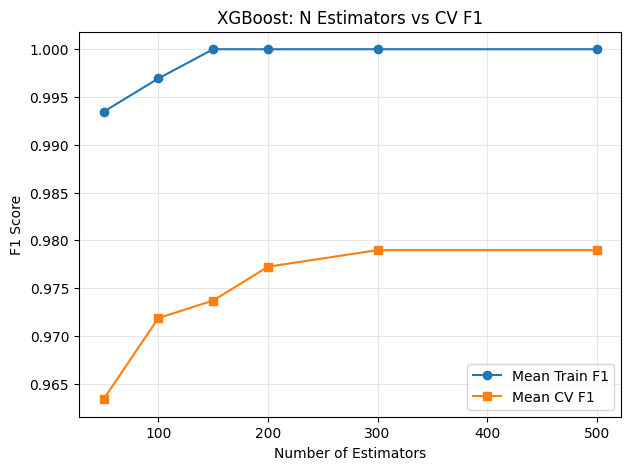

Best structure parameters: {'max_depth': 3, 'min_child_weight': 1}
Best structure CV F1: 0.978974937310106
    param_max_depth  param_min_child_weight  mean_train_score  \
8                 3                       1          1.000000   
1                 1                       3          0.992147   
5                 2                       3          0.995635   
4                 2                       1          1.000000   
17                5                       3          0.996942   
13                4                       3          0.996505   
9                 3                       3          0.996505   
0                 1                       1          0.994326   
16                5                       1          1.000000   
6                 2                       5          0.992587   

    mean_test_score  std_test_score  rank_test_score  
8          0.978975        0.015290                1  
1          0.977510        0.008734                2  
5          0

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

from xgboost import XGBClassifier

#1.准备数据
data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True, #划分前先打乱
    random_state=42
)

#2.找n_estimators
base_model = XGBClassifier( #建立基准模型
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=1, #越小，则小节点越容易形成，越容易过拟合
    gamma=0,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    eval_metric="logloss"
)

param_grid_n = {
    "n_estimators": [50, 100, 150, 200, 300, 500]
}

grid_n = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid_n,
    scoring="f1",
    cv=cv,
    n_jobs=-1, #尽量使用可用 CPU 核心并行执行 CV 训练
    return_train_score=True
)

grid_n.fit(X_train, y_train)

print("Best n_estimators:", grid_n.best_params_)
print("Best CV F1:", grid_n.best_score_)

n_results = pd.DataFrame(grid_n.cv_results_)

n_results = n_results[
    [
        "param_n_estimators",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
]

n_results = n_results.sort_values("param_n_estimators")

print(n_results)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    n_results["param_n_estimators"],
    n_results["mean_train_score"],
    marker="o",
    label="Mean Train F1"
)

ax.plot(
    n_results["param_n_estimators"],
    n_results["mean_test_score"],
    marker="s",
    label="Mean CV F1"
)

ax.set_xlabel("Number of Estimators")
ax.set_ylabel("F1 Score")
ax.set_title("XGBoost: N Estimators vs CV F1")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

#3.调试max_depth和min_child_weight
best_n_estimators = grid_n.best_params_["n_estimators"]

model_structure = XGBClassifier(
    n_estimators=best_n_estimators,
    learning_rate=0.05,
    gamma=0,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    eval_metric="logloss"
)

param_grid_structure = {
    "max_depth": [1, 2, 3, 4, 5],
    "min_child_weight": [1, 3, 5, 7]
}

grid_structure = GridSearchCV(
    estimator=model_structure,
    param_grid=param_grid_structure,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_structure.fit(X_train, y_train)

print("Best structure parameters:", grid_structure.best_params_)
print("Best structure CV F1:", grid_structure.best_score_)

structure_results = pd.DataFrame(grid_structure.cv_results_)

structure_results = structure_results[
    [
        "param_max_depth",
        "param_min_child_weight",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
]

structure_results = structure_results.sort_values("rank_test_score")

print(structure_results.head(10))

#4.调gamma
best_depth = grid_structure.best_params_["max_depth"]
best_child_weight = grid_structure.best_params_["min_child_weight"]

model_gamma = XGBClassifier(
    n_estimators=best_n_estimators,
    learning_rate=0.05,
    max_depth=best_depth,
    min_child_weight=best_child_weight,
    subsample=1.0,
    colsample_bytree=1.0,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    eval_metric="logloss"
)

param_grid_gamma = {
    "gamma": [0, 0.05, 0.1, 0.2, 0.5, 1]
}

grid_gamma = GridSearchCV(
    estimator=model_gamma,
    param_grid=param_grid_gamma,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_gamma.fit(X_train, y_train)

print("Best gamma:", grid_gamma.best_params_)
print("Best gamma CV F1:", grid_gamma.best_score_)

#5.调采样
best_gamma = grid_gamma.best_params_["gamma"]

model_sampling = XGBClassifier(
    n_estimators=best_n_estimators,
    learning_rate=0.05,
    max_depth=best_depth,
    min_child_weight=best_child_weight,
    gamma=best_gamma,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    eval_metric="logloss"
)

param_grid_sampling = {
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

grid_sampling = GridSearchCV(
    estimator=model_sampling,
    param_grid=param_grid_sampling,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

grid_sampling.fit(X_train, y_train)

print("Best sampling:", grid_sampling.best_params_)
print("Best sampling CV F1:", grid_sampling.best_score_)

#6.调正则化
best_subsample = grid_sampling.best_params_["subsample"]
best_colsample = grid_sampling.best_params_["colsample_bytree"]

model_regularization = XGBClassifier(
    n_estimators=best_n_estimators,
    learning_rate=0.05,
    max_depth=best_depth,
    min_child_weight=best_child_weight,
    gamma=best_gamma,
    subsample=best_subsample,
    colsample_bytree=best_colsample,
    random_state=42,
    eval_metric="logloss"
)

param_grid_reg = {
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "reg_lambda": [0.1, 1, 5, 10]
}

grid_reg = GridSearchCV(
    estimator=model_regularization,
    param_grid=param_grid_reg,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_reg.fit(X_train, y_train)

print("Best regularization:", grid_reg.best_params_)
print("Best regularization CV F1:", grid_reg.best_score_)

#7.微调learning_rate+n_estimators
best_alpha = grid_reg.best_params_["reg_alpha"]
best_lambda = grid_reg.best_params_["reg_lambda"]

model_final_tuning = XGBClassifier(
    max_depth=best_depth,
    min_child_weight=best_child_weight,
    gamma=best_gamma,
    subsample=best_subsample,
    colsample_bytree=best_colsample,
    reg_alpha=best_alpha,
    reg_lambda=best_lambda,
    random_state=42,
    eval_metric="logloss"
)

param_grid_final = {
    "learning_rate": [0.01, 0.03, 0.05, 0.08],
    "n_estimators": [100, 200, 300, 500, 800]
}

grid_final = GridSearchCV(
    estimator=model_final_tuning,
    param_grid=param_grid_final,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_final.fit(X_train, y_train)

print("Best final boosting parameters:", grid_final.best_params_)
print("Best final CV F1:", grid_final.best_score_)

#8.最终参数
best_params = {
    "learning_rate": grid_final.best_params_["learning_rate"],
    "n_estimators": grid_final.best_params_["n_estimators"],
    "max_depth": best_depth,
    "min_child_weight": best_child_weight,
    "gamma": best_gamma,
    "subsample": best_subsample,
    "colsample_bytree": best_colsample,
    "reg_alpha": best_alpha,
    "reg_lambda": best_lambda
}

print(best_params)

final_xgb = XGBClassifier(
    **best_params,
    random_state=42,
    eval_metric="logloss"
)

final_xgb.fit(X_train, y_train)

#9.X_test
y_test_pred = final_xgb.predict(X_test)
y_test_proba = final_xgb.predict_proba(X_test)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)

print("Final Test Accuracy:", test_accuracy)
print("Final Test Precision:", test_precision)
print("Final Test Recall:", test_recall)
print("Final Test F1:", test_f1)
print("Final Test AUC:", test_auc)

## 最终参数诊断模板
欠拟合：  
Train 低  
Validation 低  
gap 小  

考虑：
max_depth ↑  
min_child_weight ↓  
gamma ↓  
n_estimators ↑  
正则 ↓  

过拟合：
Train 高  
Validation 明显低  
gap 大   

考虑：
max_depth ↓  
min_child_weight ↑  
gamma ↑  
subsample ↓  
colsample ↓  
reg_alpha ↑  
reg_lambda ↑  
learning_rate ↓  

比较健康：
Train 高  
Validation 高  
gap 可接受  
std 较小  

## 标准 XGBoost 调参模板
算法：XGBoost  

正式调参顺序：  

Step 1  
固定较小 learning_rate  
例如 0.05，0.1  

Step 2  
用 CV 找合理 n_estimators  

Step 3  
调：  
max_depth  
min_child_weight  

Step 4  
调：  
gamma  

Step 5  
调：  
subsample  
colsample_bytree  

Step 6  
调：  
reg_alpha  
reg_lambda  

Step 7  
重新微调：  
learning_rate  
n_estimators  

Step 8  
组合 best_params  

Step 9  
完整 X_train 重新 fit  

Step 10  
Final Test   

# Day15:AdaBoost

AdaBoost Train Accuracy: 0.9846153846153847
AdaBoost Test Accuracy: 0.956140350877193
AdaBoost Test Precision: 0.9466666666666667
AdaBoost Test Recall: 0.9861111111111112
AdaBoost Test F1: 0.9659863945578231
AdaBoost ROC AUC: 0.9894179894179894
   n_estimators  train_accuracy  test_accuracy
0            10        0.951648       0.938596
1            20        0.956044       0.938596
2            50        0.982418       0.956140
3           100        0.984615       0.956140
4           200        0.991209       0.956140
5           300        0.997802       0.956140


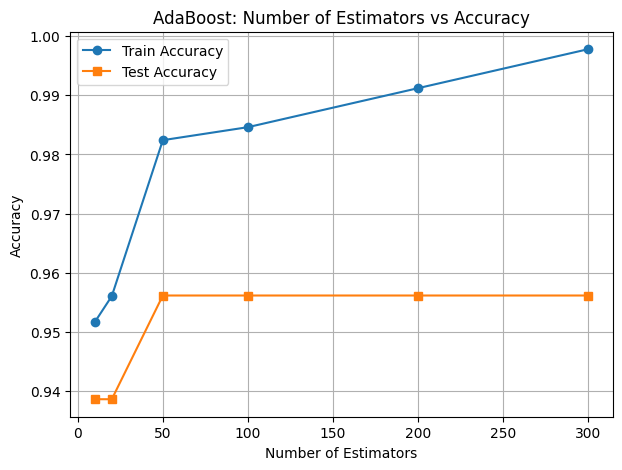

   learning_rate  train_accuracy  test_accuracy
0           0.01        0.949451       0.938596
1           0.05        0.980220       0.947368
2           0.10        0.984615       0.956140
3           0.50        1.000000       0.956140
4           1.00        1.000000       0.956140


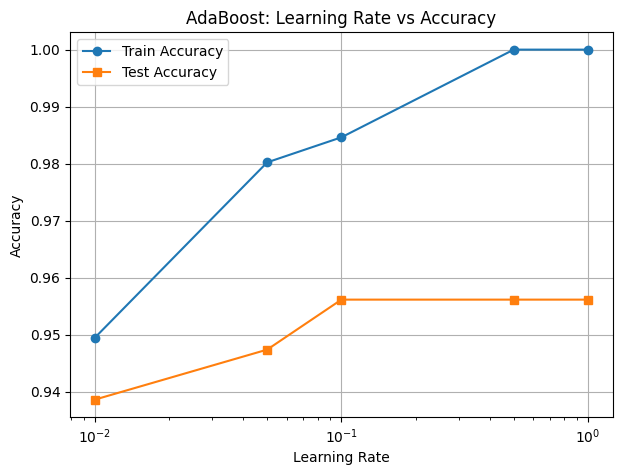

   max_depth  train_accuracy  test_accuracy
0          1        0.984615       0.956140
1          2        1.000000       0.956140
2          3        1.000000       0.964912
3          4        1.000000       0.929825
4          5        1.000000       0.929825


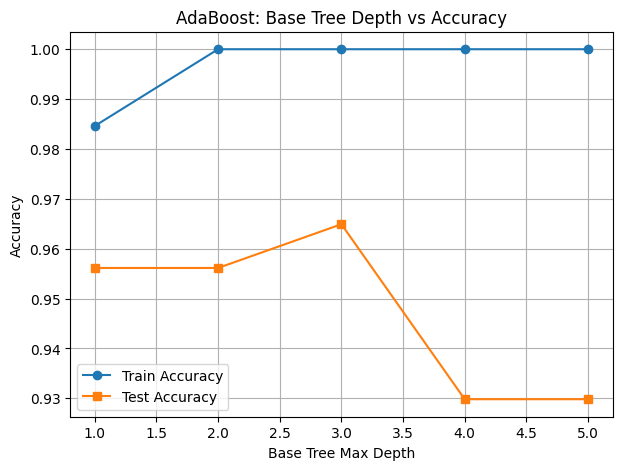

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

base_tree = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

ada_model = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ada_model.fit(X_train, y_train)

y_train_pred = ada_model.predict(X_train)
y_test_pred = ada_model.predict(X_test)
y_test_proba = ada_model.predict_proba(X_test)[:, 1]

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)

print("AdaBoost Train Accuracy:", train_accuracy)
print("AdaBoost Test Accuracy:", test_accuracy)
print("AdaBoost Test Precision:", test_precision)
print("AdaBoost Test Recall:", test_recall)
print("AdaBoost Test F1:", test_f1)
print("AdaBoost ROC AUC:", test_auc)

#可视化诊断
#n_estimators vs Accuracy
n_estimators_list = [10, 20, 50, 100, 200, 300]

n_results = []

for n_estimators in n_estimators_list:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=n_estimators,
        learning_rate=0.1,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)

    n_results.append({
        "n_estimators": n_estimators,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy
    })

n_df = pd.DataFrame(n_results)

print(n_df)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    n_df["n_estimators"],
    n_df["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

ax.plot(
    n_df["n_estimators"],
    n_df["test_accuracy"],
    marker="s",
    label="Test Accuracy"
)

ax.set_title("AdaBoost: Number of Estimators vs Accuracy")
ax.set_xlabel("Number of Estimators")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True)

plt.show()

#learning_rate vs Accuracy
learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]

lr_results = []

for learning_rate in learning_rates:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=100,
        learning_rate=learning_rate,
        random_state=42
    )

    model.fit(X_train, y_train)

    lr_results.append({
        "learning_rate": learning_rate,
        "train_accuracy": model.score(X_train, y_train),
        "test_accuracy": model.score(X_test, y_test)
    })

lr_df = pd.DataFrame(lr_results)

print(lr_df)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    lr_df["learning_rate"],
    lr_df["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

ax.plot(
    lr_df["learning_rate"],
    lr_df["test_accuracy"],
    marker="s",
    label="Test Accuracy"
)

ax.set_xscale("log")
ax.set_title("AdaBoost: Learning Rate vs Accuracy")
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True)

plt.show()

#弱学习器深度
depth_list = [1, 2, 3, 4, 5]

depth_results = []

for depth in depth_list:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=depth, random_state=42),
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    )

    model.fit(X_train, y_train)

    depth_results.append({
        "max_depth": depth,
        "train_accuracy": model.score(X_train, y_train),
        "test_accuracy": model.score(X_test, y_test)
    })

depth_df = pd.DataFrame(depth_results)

print(depth_df)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    depth_df["max_depth"],
    depth_df["train_accuracy"],
    marker="o",
    label="Train Accuracy"
)

ax.plot(
    depth_df["max_depth"],
    depth_df["test_accuracy"],
    marker="s",
    label="Test Accuracy"
)

ax.set_title("AdaBoost: Base Tree Depth vs Accuracy")
ax.set_xlabel("Base Tree Max Depth")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True)

plt.show()

## 算法名称：AdaBoost  
  
全称：  
Adaptive Boosting  
  
所属体系：  
Ensemble Learning → Boosting  

一、核心思想  

多个弱学习器串行训练。  

前一轮错分样本：  
→ 提高权重  
→ 后一轮更加关注  

表现更好的弱学习器：  
→ 最终组合权重更高  


二、核心参数  

estimator：  
基学习器，常用浅层决策树。  

n_estimators：  
弱学习器数量。  

learning_rate：  
每轮弱学习器贡献大小。  

base tree max_depth：  
控制单个弱学习器复杂度。  


三、fit 过程  

初始化样本权重  
↓  
训练弱学习器  
↓  
计算加权错误率  
↓  
提高错分样本权重  
↓  
训练下一弱学习器  
↓  
多个弱学习器加权组合  


四、分类代码  

from sklearn.tree import DecisionTreeClassifier  
from sklearn.ensemble import AdaBoostClassifier  

base_tree = DecisionTreeClassifier(  
    max_depth=1,  
    random_state=42  
)  

model = AdaBoostClassifier(  
    estimator=base_tree,  
    n_estimators=100,  
    learning_rate=0.1,  
    random_state=42  
)  

model.fit(X_train, y_train)  

y_pred = model.predict(X_test)  
y_proba = model.predict_proba(X_test)[:, 1]  


五、是否需要标准化  

通常不需要。  

前提：  
基学习器为决策树。  


六、优点  

思想简单  
弱学习器可组合成强模型  
参数相对较少  


七、缺点  

对异常值和标签噪声较敏感  
基学习器过强容易过拟合  
现代比赛中通常不是最高优先级  


八、与 GBDT 区别  

AdaBoost：  
通过调整样本权重关注难样本。  

GBDT：  
通过拟合损失函数负梯度修正模型。  


九、何时考虑  

中小型分类任务  
作为 Boosting baseline  
用于和 RF / GBDT / XGB / LGBM / CatBoost 对照  

# Day16:模型排行榜

                 model  mean_train_f1  mean_validation_f1  \
0  Logistic Regression       0.991274            0.982544   
1              XGBoost       1.000000            0.980774   
2             CatBoost       1.000000            0.979035   
3                  SVC       0.988249            0.975615   
4                  KNN       0.981343            0.970489   
5        Random Forest       1.000000            0.970027   
6             AdaBoost       0.990401            0.968602   
7             LightGBM       1.000000            0.966860   
8                 GBDT       1.000000            0.961363   

   train_validation_gap  std_validation_f1  
0              0.008730           0.007752  
1              0.019226           0.015170  
2              0.020965           0.013242  
3              0.012633           0.011252  
4              0.010854           0.009111  
5              0.029973           0.014628  
6              0.021799           0.011937  
7              0.033140      

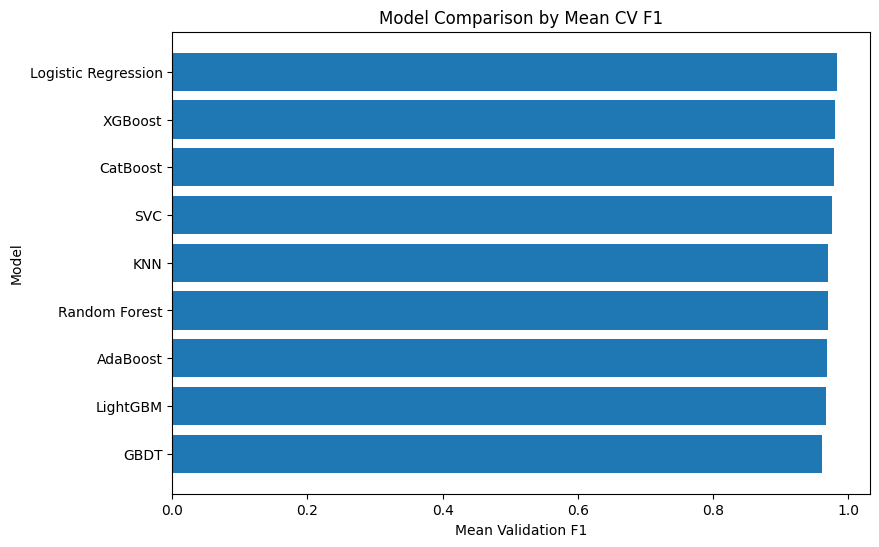

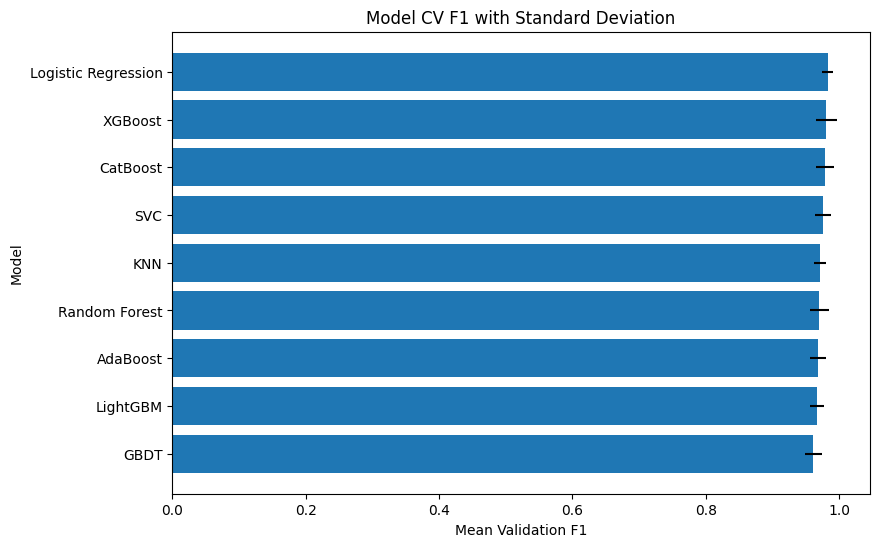

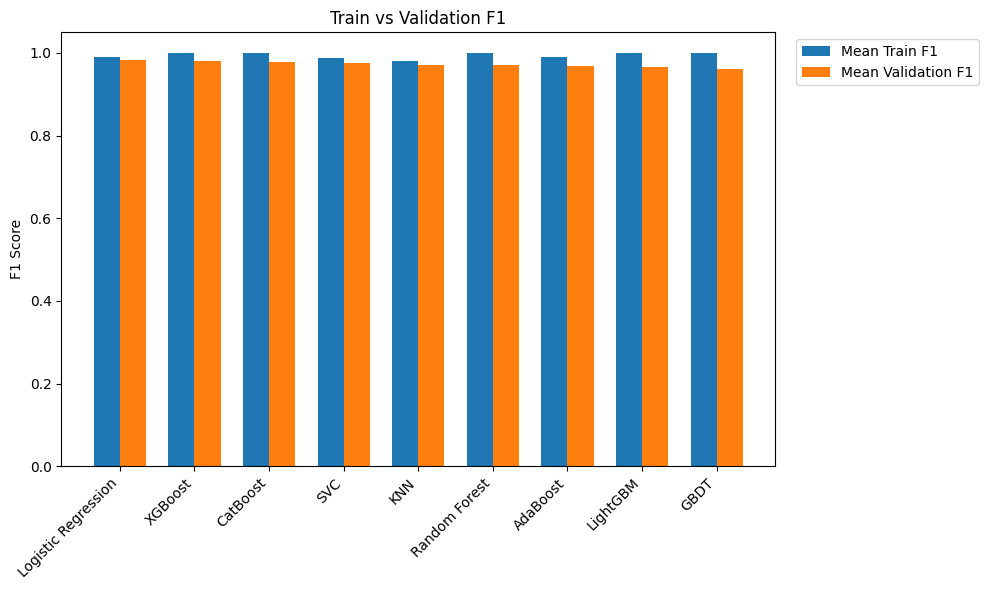

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

#1.数据准备
data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#2.建立统一CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#3.标准化➕创建模型（Logistic Regression、KNN、SVC）
#Logistic Regression
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

#KNN
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(
        n_neighbors=5
    ))
])

#SVC
svc_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale"
    ))
])

#4.创建模型
#Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

#GBDT
gbdt_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)


#AdaBoost
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

#XGBoost（调用day14参数）
xgb_model = XGBClassifier(
    learning_rate=0.05,
    n_estimators=300,
    max_depth=3,
    min_child_weight=1,
    gamma=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    eval_metric="logloss"
)

#LightGBM
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    num_leaves=15,
    min_child_samples=20,
    random_state=42,
    verbosity=-1
)

#CatBoost
cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=False
)

#5.建立models字典
models = {
    "Logistic Regression": logistic_model,
    "KNN": knn_model,
    "SVC": svc_model,
    "Random Forest": rf_model,
    "AdaBoost": ada_model,
    "GBDT": gbdt_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost": cat_model
}

#6.运行CV
results = []

for name, model in models.items():
    cv_result = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        return_train_score=True,
        n_jobs=-1
    )

    results.append({
        "model": name,
        "mean_train_f1": cv_result["train_score"].mean(),
        "mean_validation_f1": cv_result["test_score"].mean(),
        "train_validation_gap":cv_result["train_score"].mean()-cv_result["test_score"].mean(),
        "std_validation_f1": cv_result["test_score"].std()
    })

#7.生成模型排行榜
ranking_df = pd.DataFrame(results)

ranking_df = ranking_df.sort_values(
    "mean_validation_f1",
    ascending=False
)

ranking_df = ranking_df.reset_index(drop=True)

print(ranking_df)

#8.可视化诊断
#模型 CV F1 排行榜
plot_df = ranking_df.sort_values("mean_validation_f1")

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    plot_df["model"],
    plot_df["mean_validation_f1"]
)

ax.set_xlabel("Mean Validation F1")
ax.set_ylabel("Model")
ax.set_title("Model Comparison by Mean CV F1")

plt.show()

#带标准差的排行榜
fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    plot_df["model"],
    plot_df["mean_validation_f1"],
    xerr=plot_df["std_validation_f1"] #横向误差线长度 = CV F1 标准差
)

ax.set_xlabel("Mean Validation F1")
ax.set_ylabel("Model")
ax.set_title("Model CV F1 with Standard Deviation")

plt.show()

#Train vs Validation
#哪个模型可能过拟合
x = np.arange(len(ranking_df)) #生成[0,1,...,7,8]
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    x - width / 2,
    ranking_df["mean_train_f1"],
    width=width,
    label="Mean Train F1"
)

ax.bar(
    x + width / 2,
    ranking_df["mean_validation_f1"],
    width=width,
    label="Mean Validation F1"
)

ax.set_xticks(x)
ax.set_xticklabels(
    ranking_df["model"],
    rotation=45,
    ha="right"
)

ax.set_ylabel("F1 Score")
ax.set_title("Train vs Validation F1")
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.02,1)
    )

plt.tight_layout()
plt.show()

## 模型家族复盘标准版 
Logistic Regression

所属家族：
Linear Model

通常需要标准化：
建议，尤其带正则化时


KNN

所属家族：
Distance-based Model

核心机制：
根据 K 个最近邻进行投票


SVC

所属家族：
Maximum Margin / Kernel Method

核心机制：
寻找最大间隔决策边界
并通过 Kernel 处理非线性


Random Forest

所属集成方式：
Bagging

核心：
Bootstrap
+
随机特征
+
多树投票


AdaBoost

核心修正机制：
提高错分样本权重
让后一轮更加关注难样本


GBDT

核心修正机制：
拟合当前损失函数负梯度


XGBoost

关键增强：
一阶 + 二阶信息
正则化
采样
高效实现


LightGBM

关键增强：
Histogram
Leaf-wise


CatBoost

关键增强：
Ordered Target Statistics,
Ordered Boosting,
原生类别特征处理